In [18]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('/home/shared/splus_gaia/notebooks/Marina/table1_all_objects_smc_lmc.csv')
df

,ra,dec,OGLE-II,OGLE-III,OGLE-IV,Offset,RemOut
0,83.31325,-70.36894,LMC_SC1_108086,LMC170.3.21,LMC516.04.19670,53,NaN
1,83.44342,-70.33486,LMC_SC1_113297,LMC170.3.73425,LMC516.04.19664,A,13.0
2,83.40288,-70.16544,LMC_SC1_124623,LMC170.4.81503,LMC516.12.2,A,19.0
3,83.32333,-70.20175,LMC_SC1_124756,LMC170.4.64358,LMC516.12.274,A,2.0
4,83.31079,-70.18892,LMC_SC1_124784,LMC170.4.64070,LMC516.12.324,12,NaN
...,...,...,...,...,...,...,...
3128,16.95675,-72.44425,SMC_SC11_84829,SMC113.1.9040,1,NaN,NaN
3129,17.10754,-72.39086,SMC_SC11_87052,SMC113.1.13308,SMC725.03.38,2,NaN
3130,17.03075,-72.32572,SMC_SC11_89099,SMC113.1.31483,SMC725.03.14404,4,NaN
3131,16.59129,-72.77789,SMC_SC11_9050,SMC110.2.15171,SMC726.28.106,3,NaN


In [1]:
td = pd.read_csv('/home/shared/splus_gaia/notebooks/Marina/splus_figueiredo_objects_all.csv')

NameError: name 'pd' is not defined

In [21]:
bes = pd.read_csv('/home/shared/splus_gaia/notebooks/Marina/be_stars_smc_lmc.csv')

In [22]:
bes['OGLE'] = bes['OGLE'].str.upper()

In [23]:
bes

,OGLE,Ori,DC,DDC,Nou,Mass,Group
0,LMC_SC1_124756,P,0.411,1.000,1.035,0.0,1
1,LMC_SC1_124784,P,0.709,1.000,0.311,0.0,1
2,LMC_SC1_124845,E,0.473,0.979,0.569,13.6,3
3,LMC_SC1_143809,P,0.473,0.920,0.762,10.3,3
4,LMC_SC1_143832,P,0.173,0.924,0.207,15.5,3
...,...,...,...,...,...,...,...
1747,SMC_SC11_79106,P,0.573,1.000,0.832,0.0,1
1748,SMC_SC11_80892,P,0.410,0.953,0.185,0.0,1
1749,SMC_SC11_84829,P,0.189,1.000,0.505,0.0,1
1750,SMC_SC11_9050,P,0.553,1.000,0.462,0.0,1


In [24]:
be = pd.merge(td, bes, right_on='OGLE', left_on='OGLE-II', how='inner')

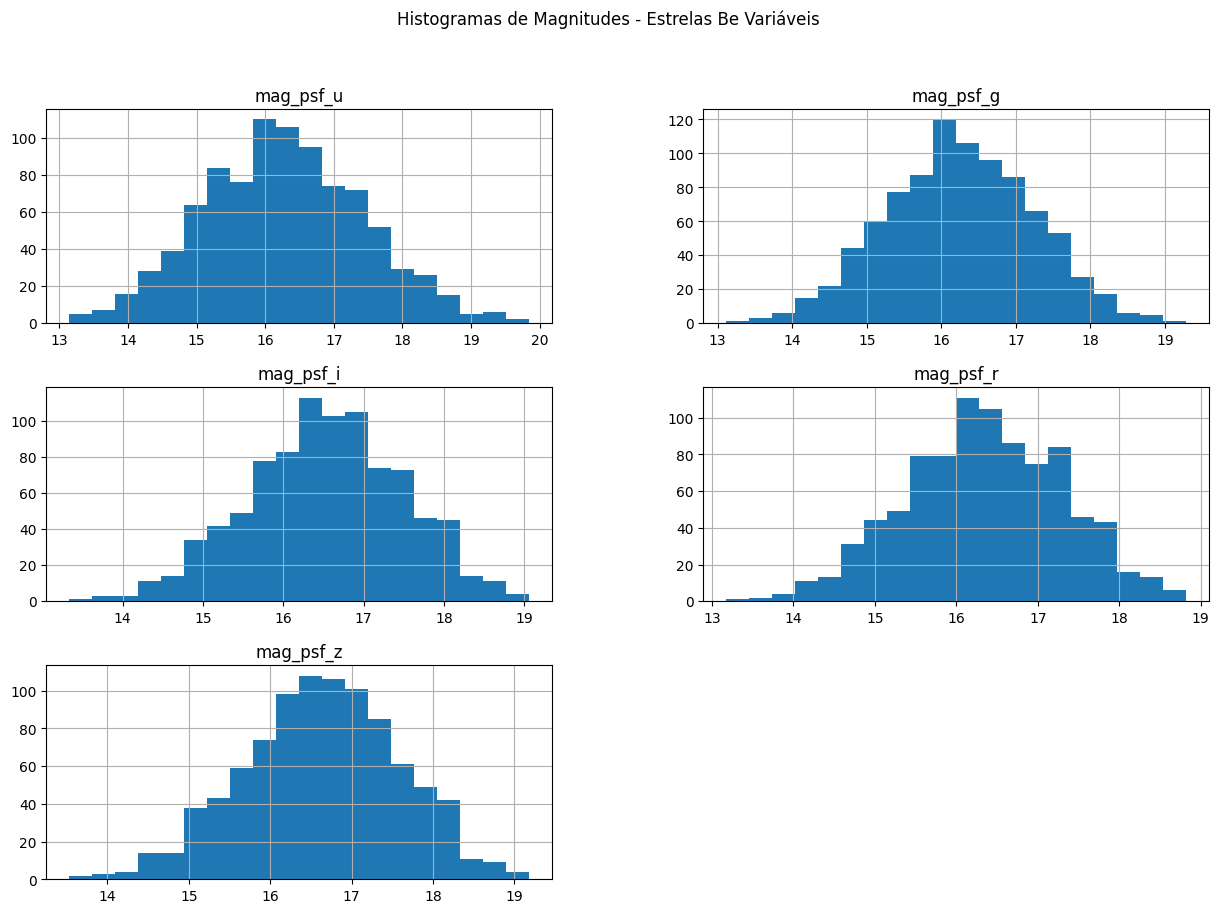

In [10]:
# faça um histograma para cada coluna de magnitude do dataframe be
be.hist(column=['mag_psf_u', 'mag_psf_g', 'mag_psf_i', 'mag_psf_r', 'mag_psf_z'], bins=20, figsize=(15,10))
plt.suptitle('Histogramas de Magnitudes - Estrelas Be Variáveis')
plt.show() 

In [26]:
meus = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all.csv')

In [27]:
match = pd.merge(be, meus, left_on='id', right_on='id', how='inner')

In [29]:
match.groupby('main_type')['id'].count()

main_type
Be*                        10
Be*_Candidate             351
Cluster*                    4
EclBin                      4
EmLine*                   105
HighMassXBin                5
HighMassXBin_Candidate      1
LongPeriodV*                1
PulsV*                      2
RGB*_Candidate             12
Star                        5
X                           2
YSO                         3
post-AGB*                   1
post-AGB*_Candidate         1
Name: id, dtype: int64

In [30]:
match2 = pd.merge(td, meus, left_on='id', right_on='id', how='inner')
len(match2)

659

# Plotting footprint

In [31]:
# read s-plus data
all_splus = pd.read_csv('/home/shared/splus_gaia/notebooks/Marina/dr6_list.csv')

#quero filtrar apenas os fields que contém MC no nome
all_splus = all_splus[all_splus['field'].str.contains("MC")]

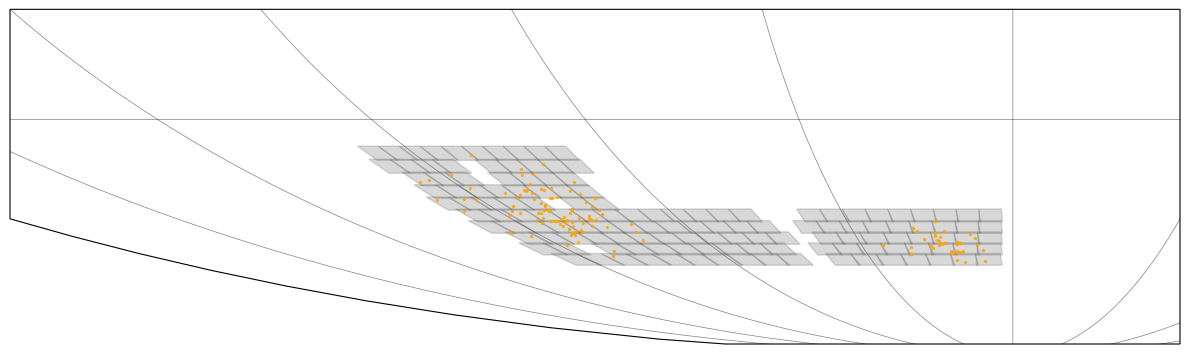

In [19]:
import pandas as pd
import numpy as np
import matplotlib.colors as colors

from matplotlib import cm
from matplotlib.patches import Polygon
from matplotlib import pyplot as plt

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import BaseEclipticFrame

import copy
import cartopy.crs as ccrs


def plot_splus_field(ra, dec, galactic=False, ax=plt, **kargs):
    
    if ra > 180:
        ra = ra - 360
    ra = -ra
    
    # Calculate corners
    dec0 = dec - 0.7
    dec1 = dec - 0.7
    dec2 = dec + 0.7
    dec3 = dec + 0.7

    ra0 = ra - 0.7/np.cos(dec0*np.pi/180)
    ra1 = ra + 0.7/np.cos(dec1*np.pi/180)
    ra2 = ra + 0.7/np.cos(dec2*np.pi/180)
    ra3 = ra - 0.7/np.cos(dec3*np.pi/180)
    
    ra = np.array([ra0, ra1, ra2, ra3, ra0])
    dec = np.array([dec0, dec1, dec2, dec3, dec0])
    
    ra[ra > 180] = ra[ra > 180] - 360   
    
    dec[dec > 90] = 90
    dec[dec < -90] = -90
    
    ax.fill(ra, dec, **kargs)


def plot_grid(ax=plt, **kwargs):
    # linhas de RA
    for ra in np.arange(-180, 180, 30):
        dera = np.arange(-90, 90, 0.1)
        rara = np.full(len(dera), ra)
        ax.plot(-rara, dera, transform=ccrs.Geodetic(),
                color="#000000", alpha=0.5, linewidth=0.5, zorder=3)

    # linhas de Dec
    for de in np.arange(-90, 90, 30):
        rade = np.arange(-180, 180, 0.1)
        dede = np.full(len(rade), de)
        ax.plot(-rade, dede, transform=ccrs.Geodetic(),
                color="#000000", alpha=0.5, linewidth=0.5, zorder=3)




def plot_points_on_footprint(df, ra_col="ra", dec_col="dec",
                             ax=None, color="red", size=20, zorder=100,
                             transform=ccrs.Geodetic(), **kwargs):

    if ax is None:
        ax = plt.gca()

    ra = df[ra_col].values.copy()
    dec = df[dec_col].values.copy()

    # Converte RA > 180 → RA - 360 (mesmo esquema do footprint)
    ra = np.where(ra > 180, ra - 360, ra)
    # Inverte para mapa celeste
    ra = -ra

    ax.scatter(ra, dec,
               s=size,
               color=color,
               transform=transform,
               zorder=zorder,
               **kwargs)


# ----------------------------
# DEFINIÇÃO LMC / SMC
# ----------------------------

lmc_ra = 15 * (5 + 23/60.)      # ~80.75 deg
lmc_de = -1 * (69 + 45/60.)     # ~ -69.75 deg

smc_ra = 15 * (0 + 52/60.)      # ~13.0 deg
smc_de = -1 * (72 + 48/60.)     # ~ -72.8 deg

lmc_center = SkyCoord(ra=lmc_ra * u.deg, dec=lmc_de * u.deg, frame="icrs")
smc_center = SkyCoord(ra=smc_ra * u.deg, dec=smc_de * u.deg, frame="icrs")

# all_splus deve ter colunas 'ra' e 'dec' dos centros dos campos
fields_coord = SkyCoord(ra=all_splus['ra'].values * u.deg,
                        dec=all_splus['dec'].values * u.deg,
                        frame="icrs")

sep_lmc = fields_coord.separation(lmc_center).deg
sep_smc = fields_coord.separation(smc_center).deg

# raios em graus – ajuste conforme seu gosto
radius_lmc = 12.0
radius_smc = 8.0

mask_mc = (sep_lmc < radius_lmc) | (sep_smc < radius_smc)
splus_mc = all_splus[mask_mc].reset_index(drop=True)

# Se quiser também restringir os PNe à região das Nuvens:
if 'pne_splus' in globals():
    pne_coord = SkyCoord(ra=pne_splus['ra'].values * u.deg,
                         dec=pne_splus['dec'].values * u.deg,
                         frame="icrs")
    sep_lmc_pne = pne_coord.separation(lmc_center).deg
    sep_smc_pne = pne_coord.separation(smc_center).deg
    mask_pne_mc = (sep_lmc_pne < radius_lmc) | (sep_smc_pne < radius_smc)
    pne_mc = pne_splus[mask_pne_mc].reset_index(drop=True)
else:
    pne_mc = None

# ----------------------------
# FIGURA APENAS COM MC
# ----------------------------

plt.figure(figsize=(12, 6))
projection = ccrs.Mollweide()
ax = plt.axes(projection=projection)

# Plot footprint S-PLUS apenas na região das Nuvens
for _, row in splus_mc.iterrows():
    plot_splus_field(row["ra"], row["dec"],
                     ax=ax,
                     transform=ccrs.Geodetic(),
                     color="#666666", alpha=0.25, zorder=50)

# Plot dos objetos (PNe) apenas na região das Nuvens
if pne_mc is not None:
    plot_points_on_footprint(
        pne_mc,
        ra_col="ra",
        dec_col="dec",
        ax=ax,
        color="orange",
        size=2,
        zorder=200,
        alpha=0.8
    )

# Opcional: dar um "zoom" aproximado na região LMC+SMC
# Lembre: o eixo x é -RA; LMC ~ -80°, SMC ~ -13°, Dec ~[-80, -50]
ax.set_extent([-120, 20, -85, -50], crs=ccrs.Geodetic())

plot_grid(ax=ax, color="#000000", alpha=0.7)
plt.tight_layout()

# Pne

In [32]:
pne = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/central_stars_pne_catalog2024_lmc_smc.csv', delimiter=',', comment='#')

In [33]:
pne_splus = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/central_stars_pne_splus.csv')

In [34]:
len(pne_splus['id'].unique())

144

In [35]:
match3 = pd.merge(meus, pne_splus, left_on='splus_idr6_id', right_on='id', how='inner', suffixes=('_meus', '_pne'))

In [36]:
len(match3['id_meus'].unique())

27

In [39]:
be

,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,mag_psf_j0515,...,OGLE-IV,ura,udec,OGLE,Ori,DC,DDC,Nou,Mass,Group
0,i06MC006502QKB,83.323564,-70.201760,16.835246,17.029380,16.814699,16.705817,16.684497,16.708429,16.759854,...,LMC516.12.274,83.32333,-70.20175,LMC_SC1_124756,P,0.411,1.000,1.035,0.0,1
1,i06MC006502XVX,83.311126,-70.188623,16.615934,16.307003,16.671294,16.554218,16.518789,16.513671,16.573671,...,LMC516.12.324,83.31079,-70.18892,LMC_SC1_124784,P,0.709,1.000,0.311,0.0,1
2,i06MC0065036AW,83.302655,-70.164758,16.330650,16.802123,16.397505,16.179976,16.132593,16.174196,16.293203,...,LMC516.12.413,83.30254,-70.16481,LMC_SC1_124845,E,0.473,0.979,0.569,13.6,3
3,i06MC00650529X,83.374666,-69.996335,15.215063,15.722150,15.115740,14.997041,15.003347,15.030706,15.188457,...,LMC516.12.27257,83.37517,-69.99631,LMC_SC1_143809,P,0.473,0.920,0.762,10.3,3
4,i06MC006505PEJ,83.362645,-69.928890,16.290084,16.588011,16.317576,16.143806,16.117773,16.139418,16.268807,...,LMC516.12.42870,83.36267,-69.92875,LMC_SC1_151200,P,0.795,1.000,0.362,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,i06MC009502UXE,16.982343,-72.585356,15.345069,15.608307,15.153553,15.152773,15.237988,15.231942,15.345255,...,SMC726.27.20523,16.98212,-72.58525,SMC_SC11_80892,P,0.410,0.953,0.185,0.0,1
926,i06MC0095040OV,16.956891,-72.444309,13.888579,14.283357,13.702030,13.647423,13.712292,13.730037,13.906904,...,1,16.95675,-72.44425,SMC_SC11_84829,P,0.189,1.000,0.505,0.0,1
927,i06MC0116091DO,16.591553,-72.778033,15.628201,15.974413,15.463746,15.339416,15.435788,15.458502,15.656265,...,SMC726.28.106,16.59129,-72.77789,SMC_SC11_9050,P,0.553,1.000,0.462,0.0,1
928,i06MC0095017JF,16.591485,-72.778000,15.594108,15.967085,15.387776,15.337892,15.436571,15.475411,15.595543,...,SMC726.28.106,16.59129,-72.77789,SMC_SC11_9050,P,0.553,1.000,0.462,0.0,1


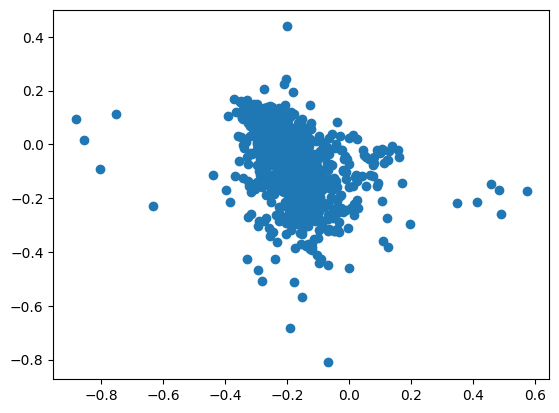

In [ ]:

plt.scatter(be['mag_psf_r'] - be['mag_psf_i'], be['mag_psf_j0660'] - be['mag_psf_r'])

In [13]:
match3.to_csv('/home/shared/splus_gaia/notebooks/Marina/match_meus_pne_splus.csv', index=False)

(array([1., 0., 2., 0., 2., 1., 1., 3., 0., 0., 4., 2., 5., 3., 1., 0., 1.,
        1., 1., 2.]),
 array([14.996693  , 15.19583715, 15.3949813 , 15.59412545, 15.7932696 ,
        15.99241375, 16.1915579 , 16.39070205, 16.5898462 , 16.78899035,
        16.9881345 , 17.18727865, 17.3864228 , 17.58556695, 17.7847111 ,
        17.98385525, 18.1829994 , 18.38214355, 18.5812877 , 18.78043185,
        18.979576  ]),
 <BarContainer object of 20 artists>)

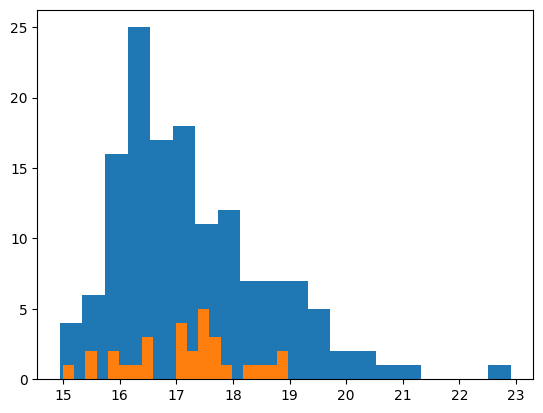

In [8]:
plt.hist(pne_splus['mag_psf_r'], bins=20)
plt.hist(match3['mag_psf_r_meus'], bins=20)

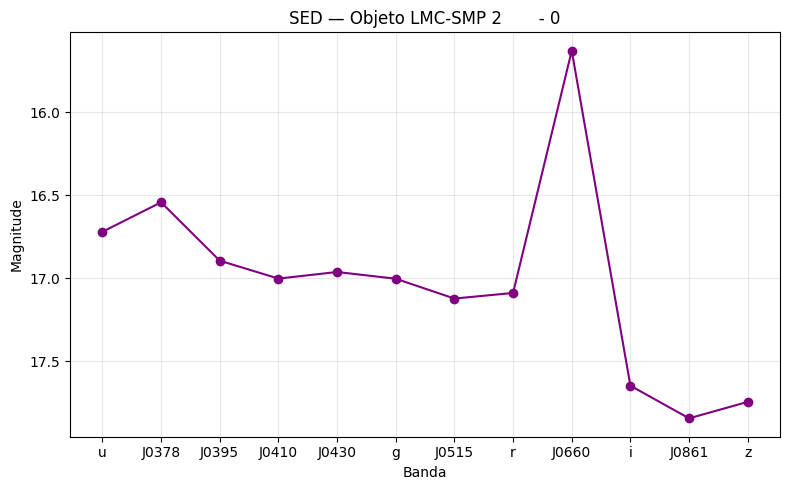

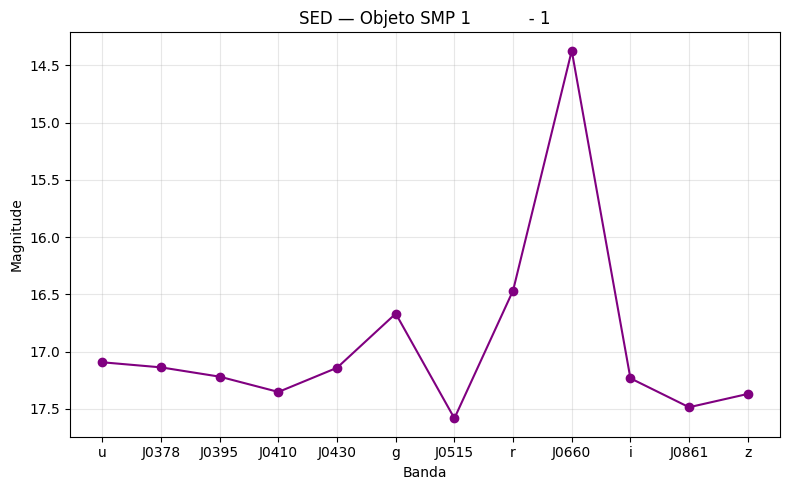

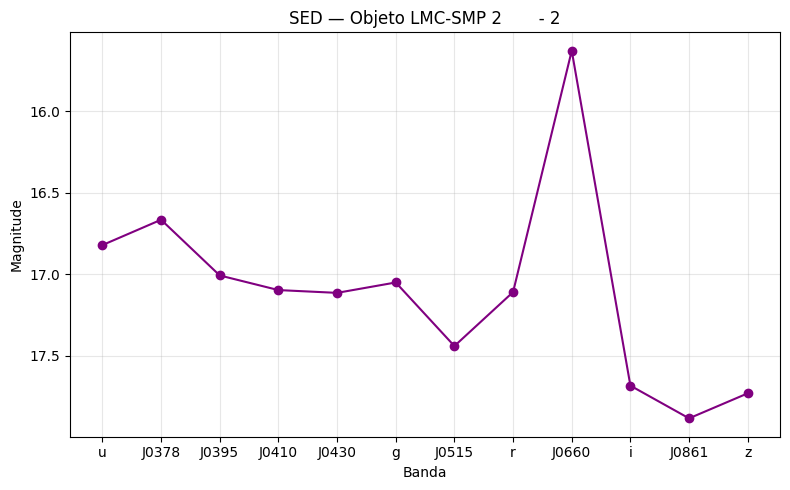

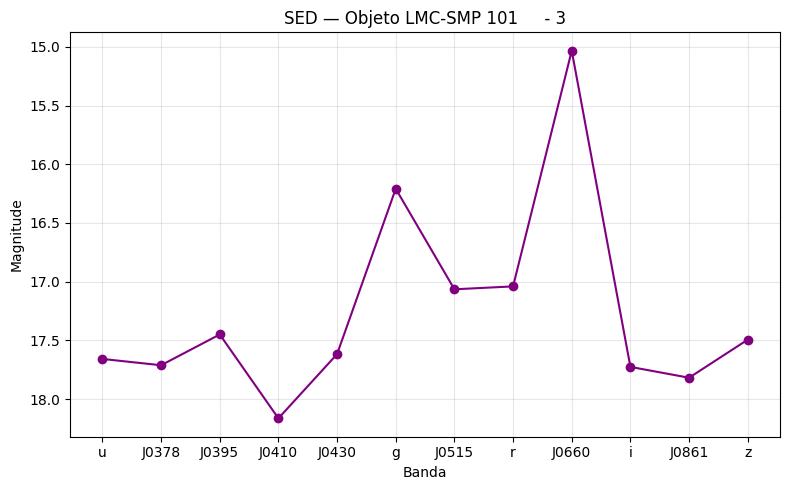

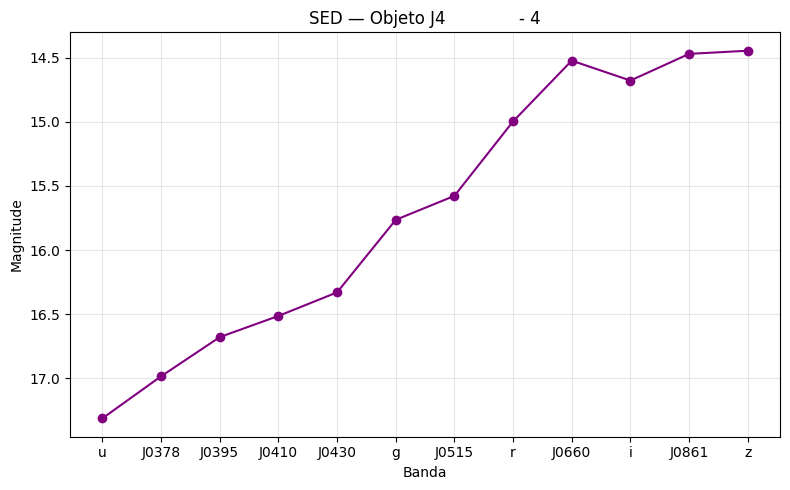

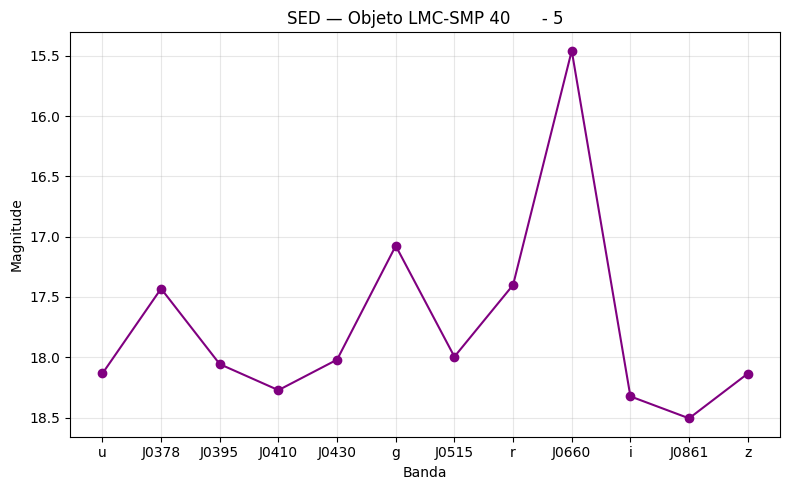

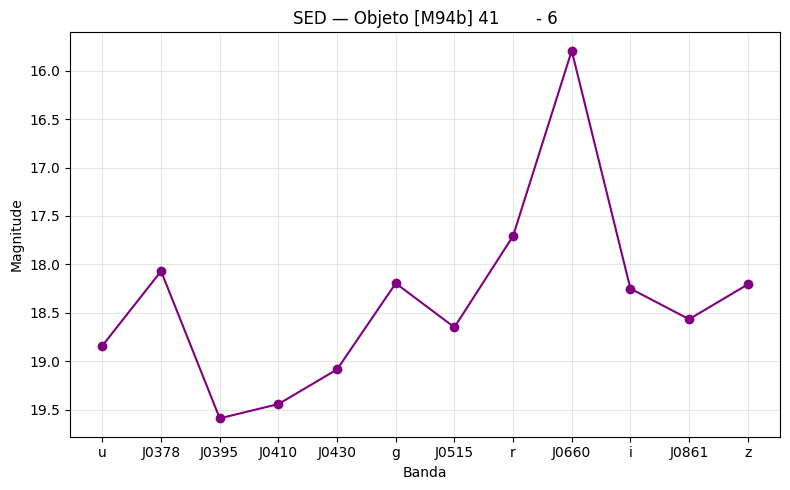

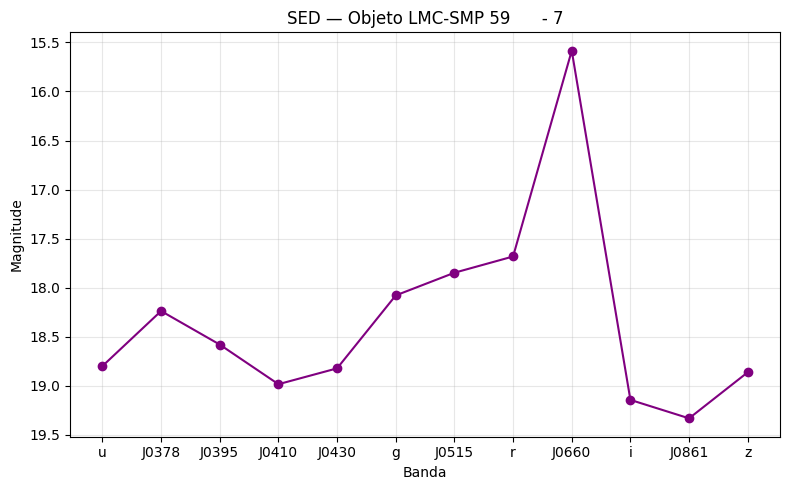

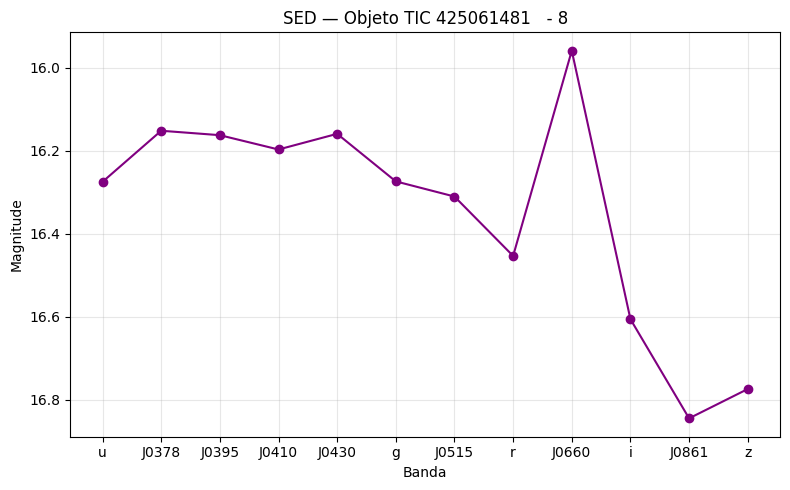

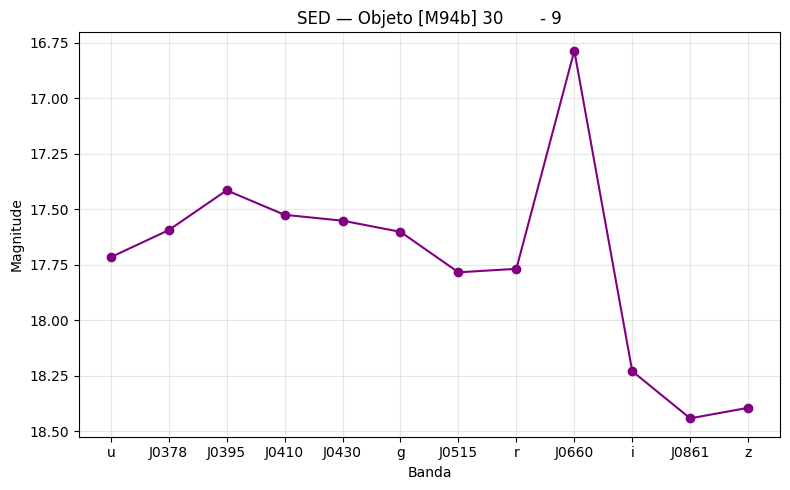

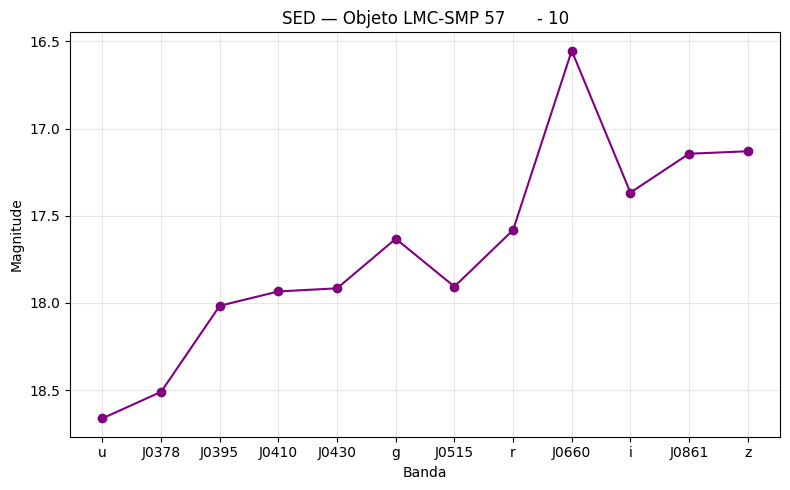

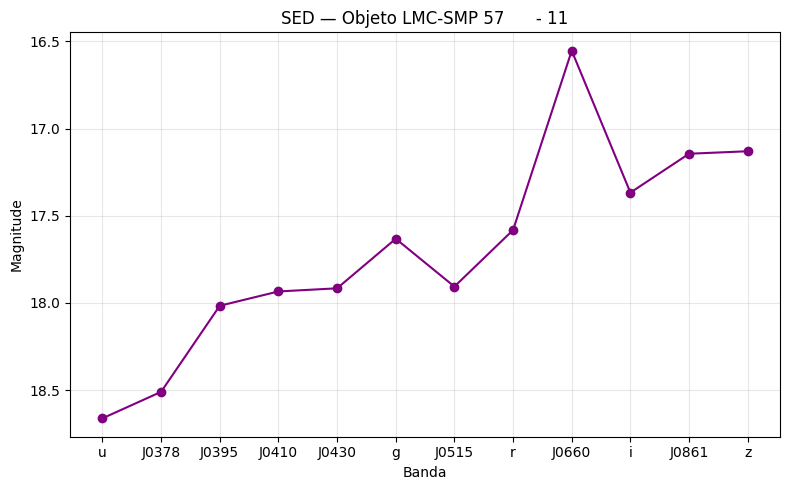

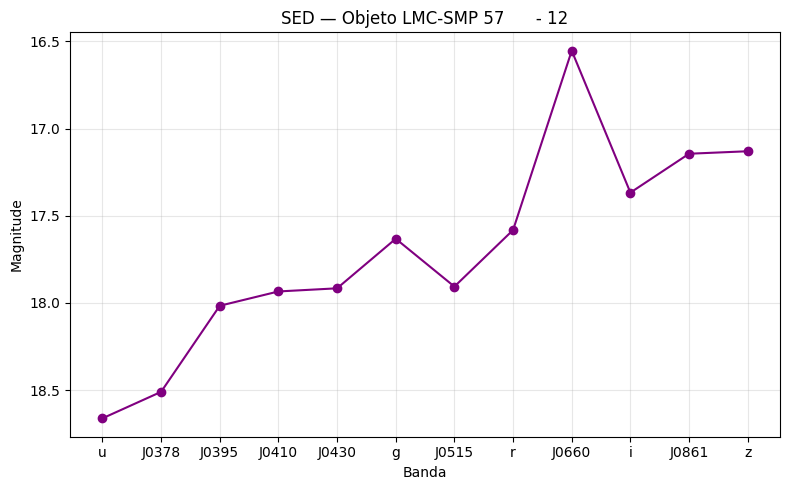

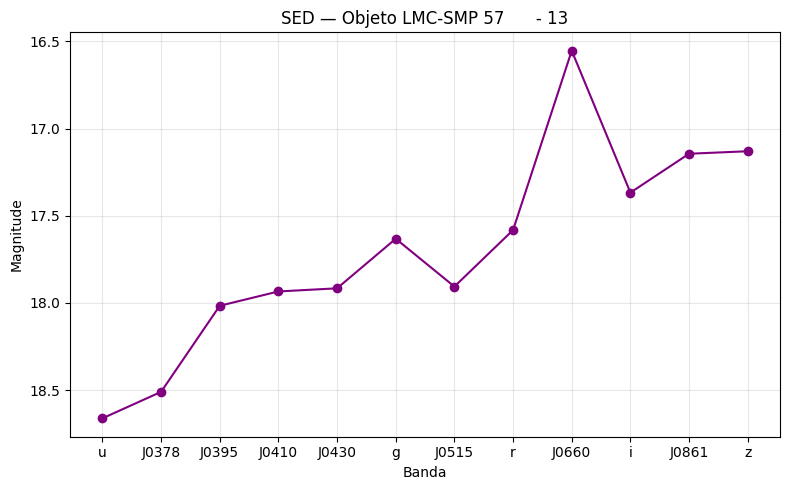

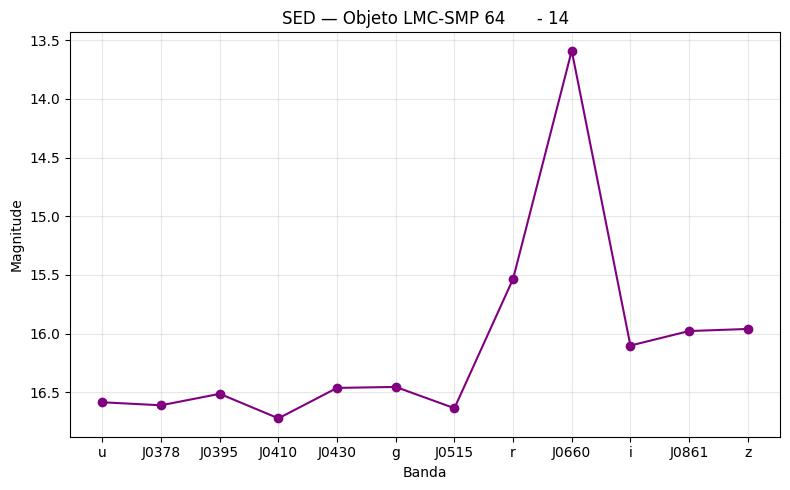

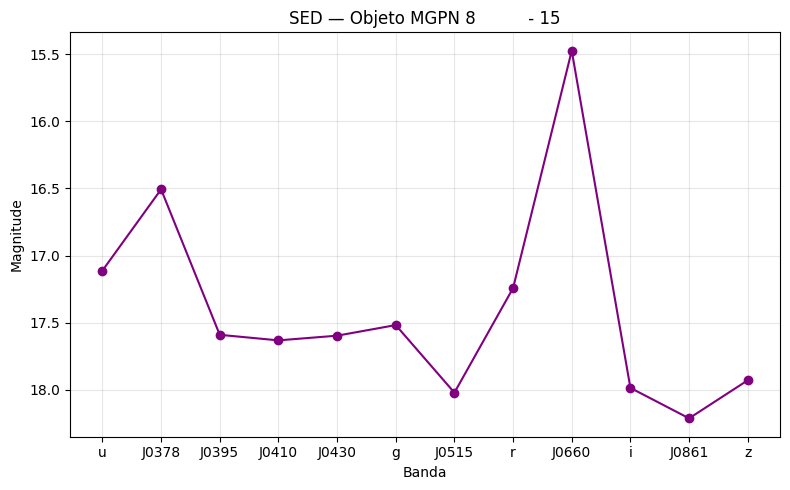

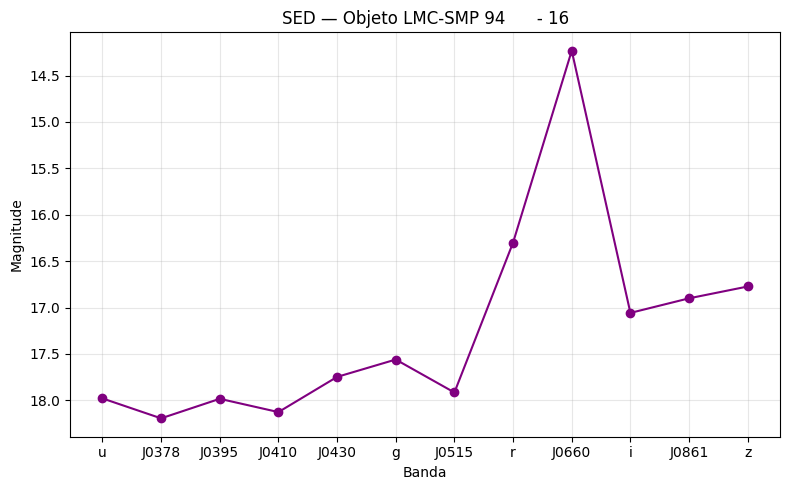

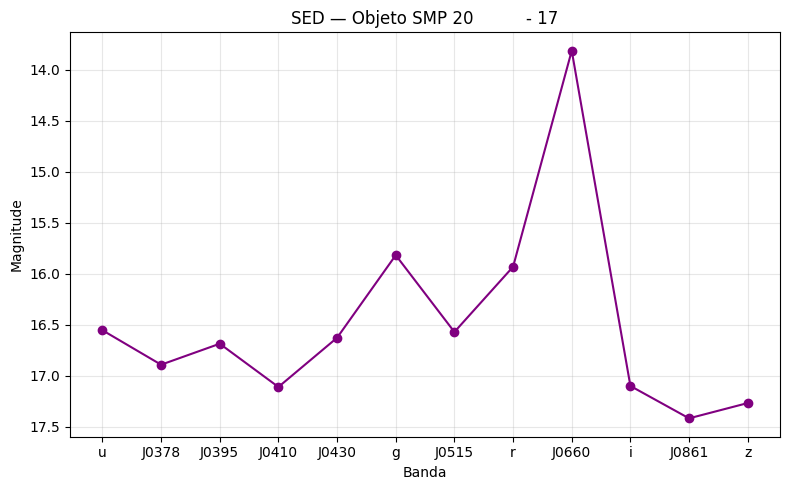

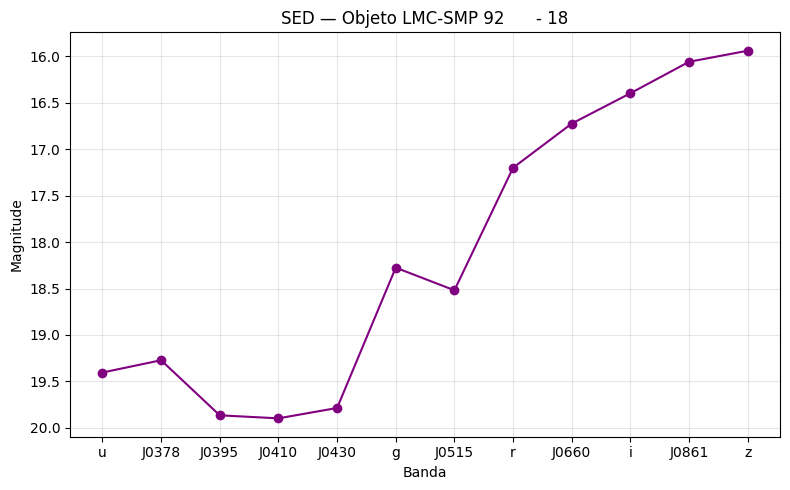

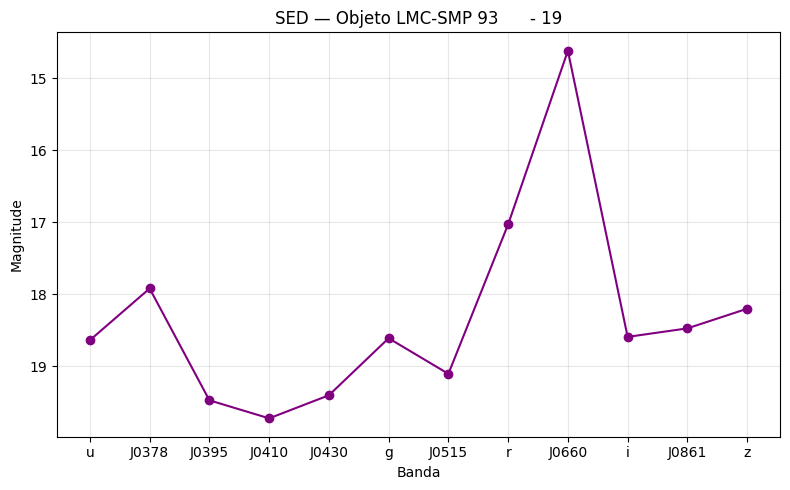

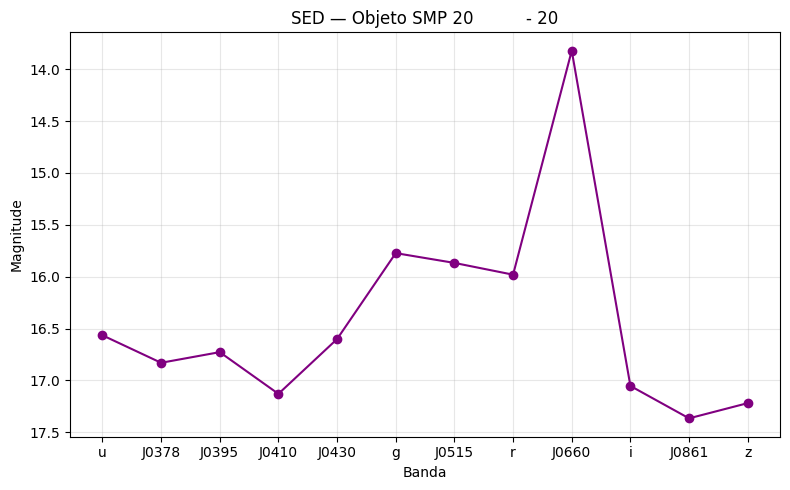

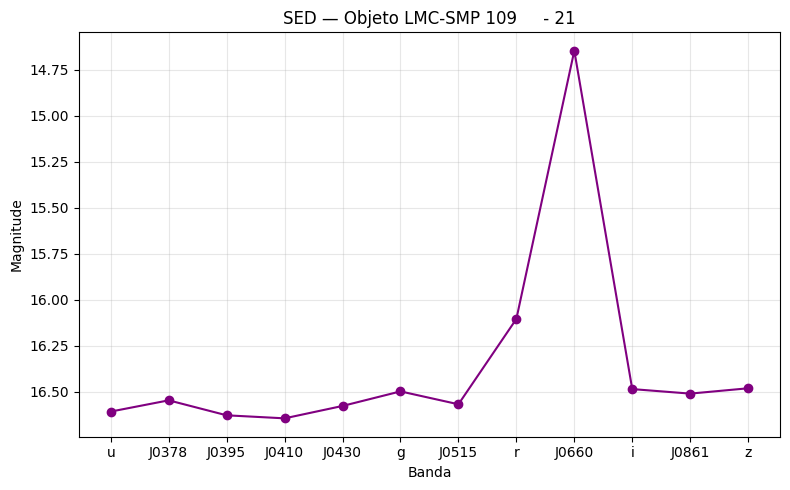

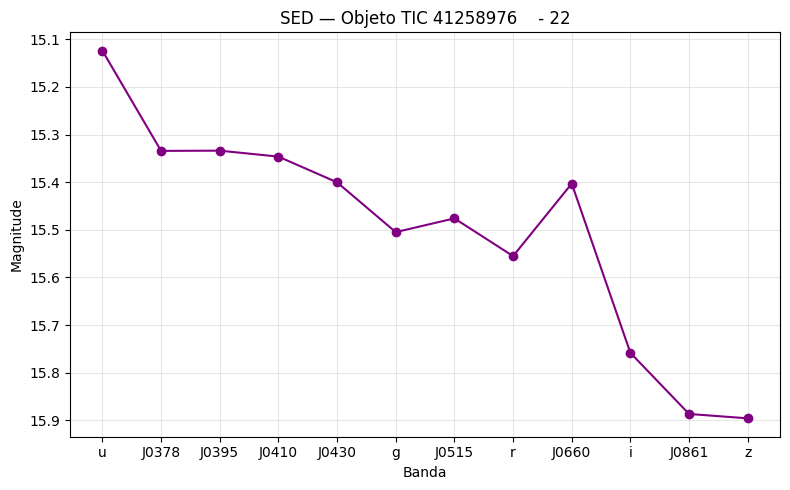

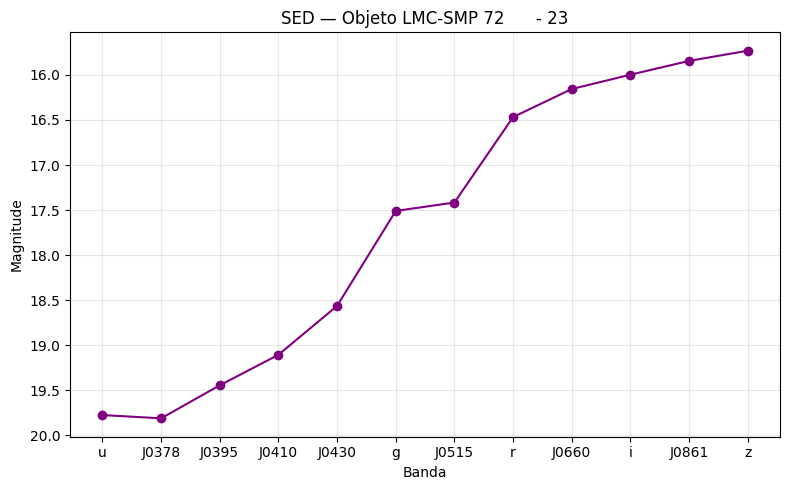

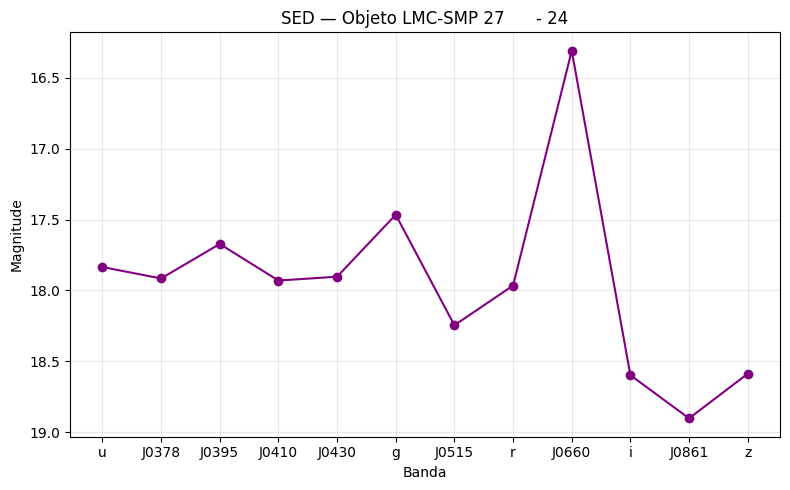

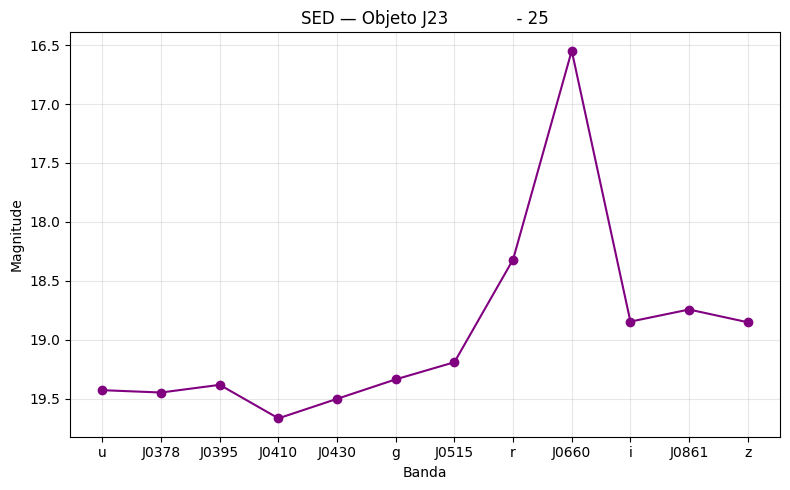

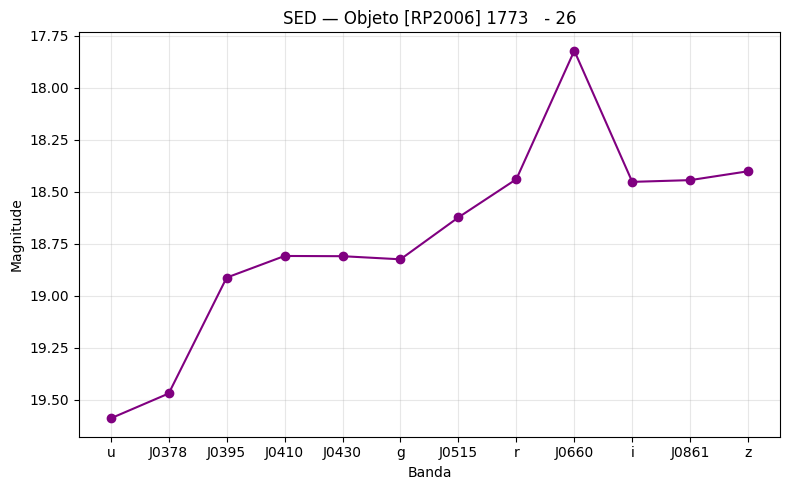

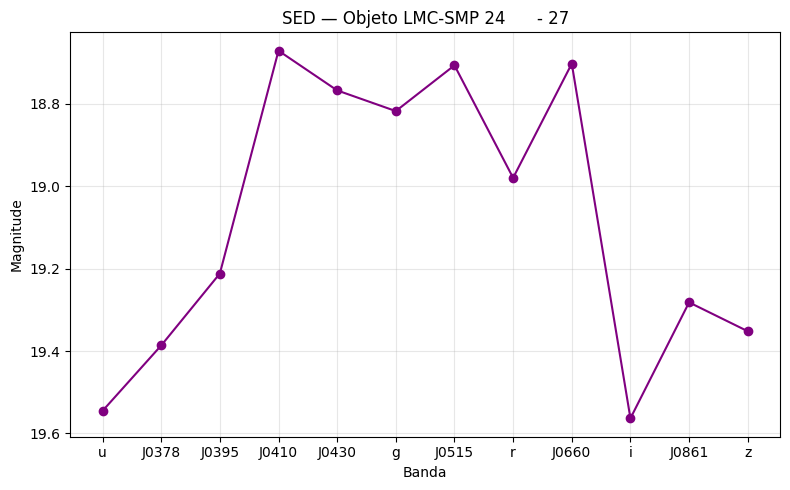

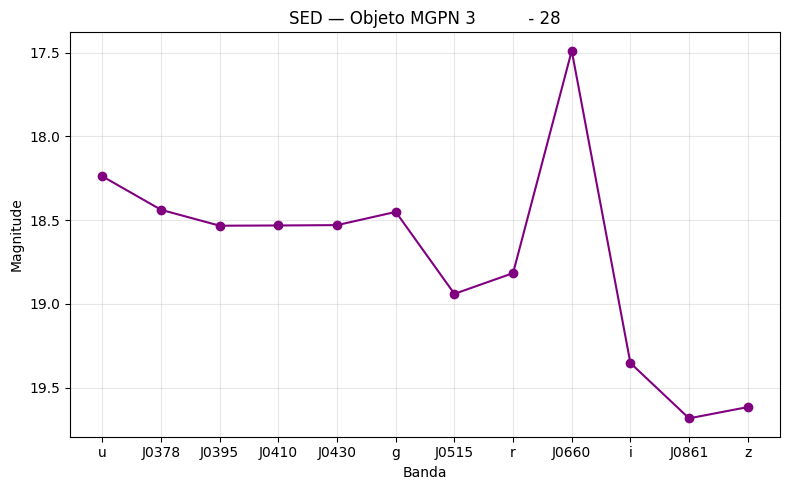

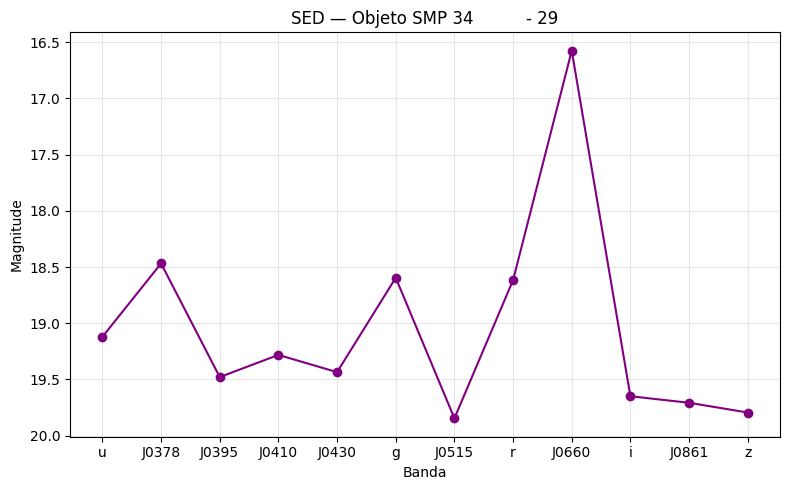

In [11]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"mag_psf_{b.lower()}_meus" for b in bands]
err_cols = [f"err_mag_psf_{b.lower()}_meus" for b in bands]
has_errors = all(col in match3.columns for col in err_cols)

i = 0
for idx, row in match3.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["Name"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

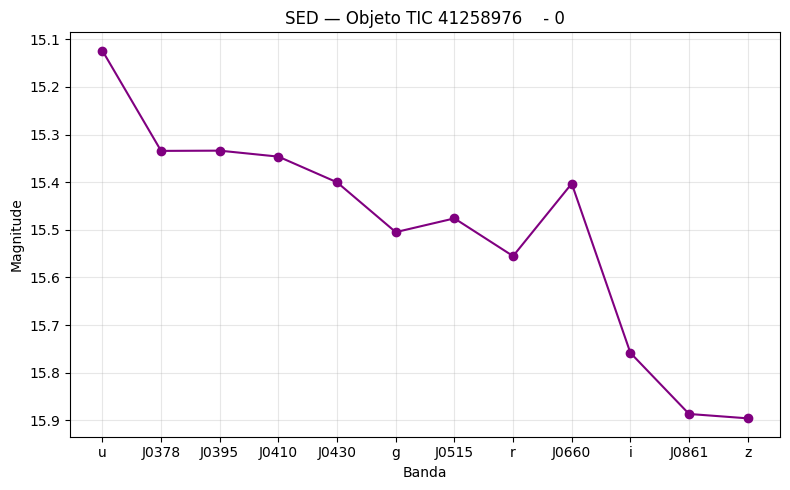

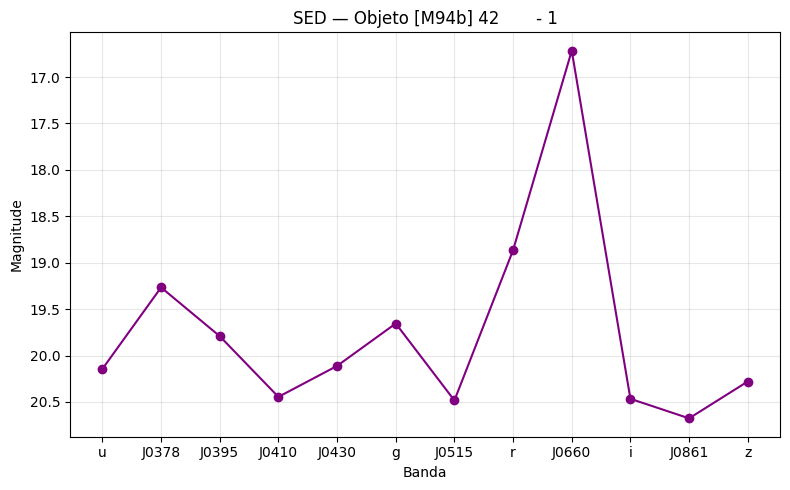

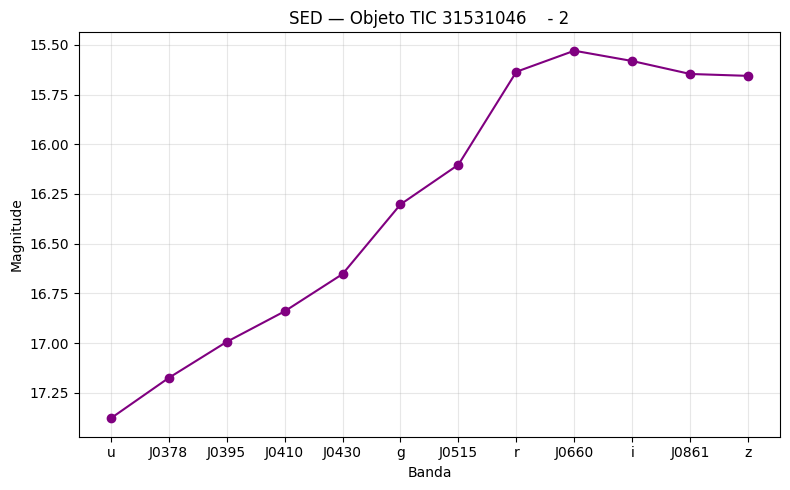

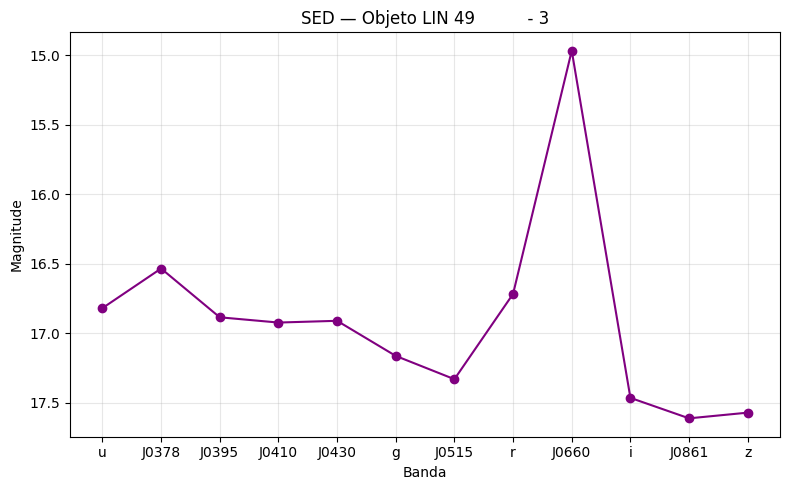

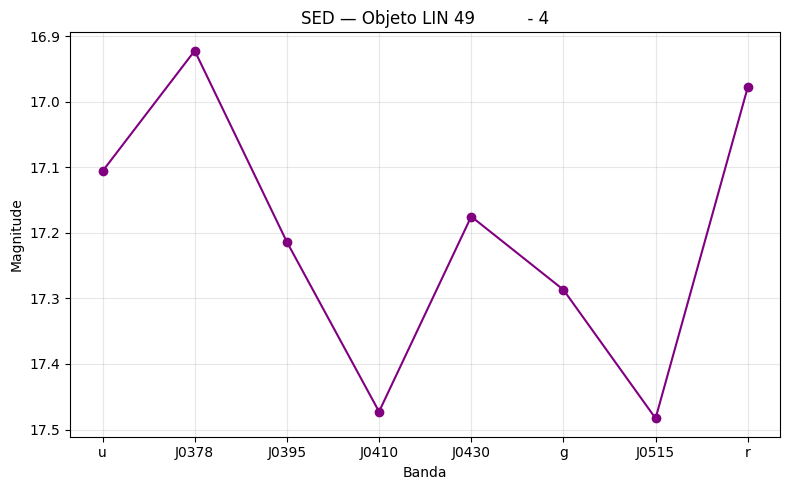

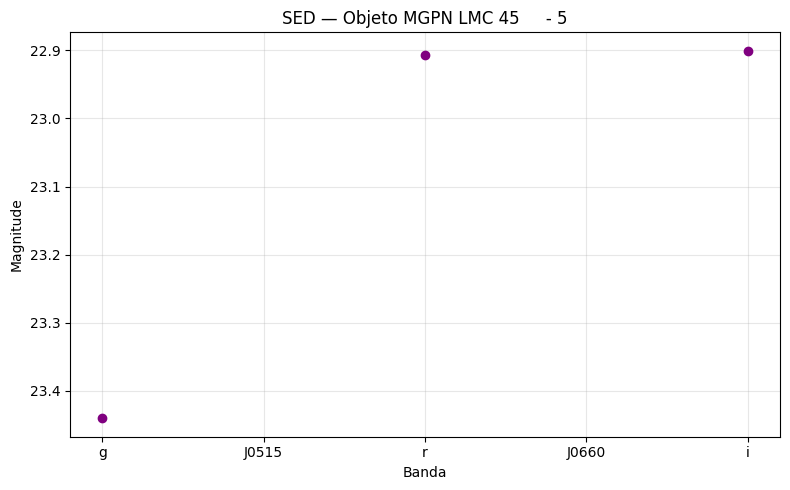

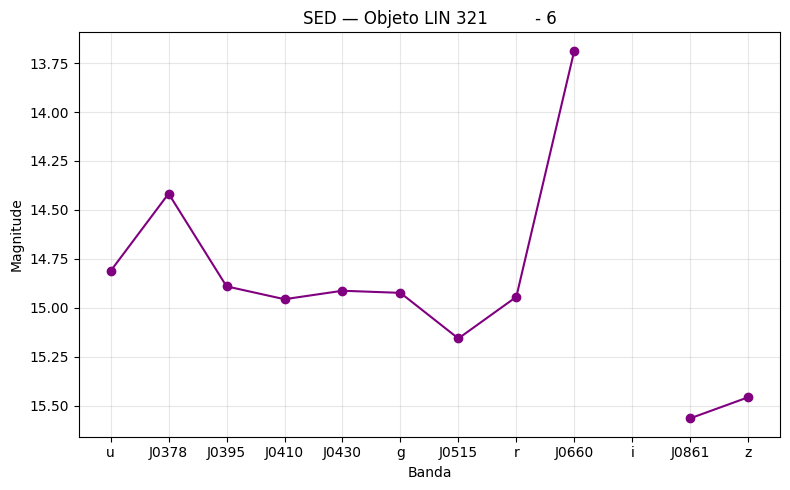

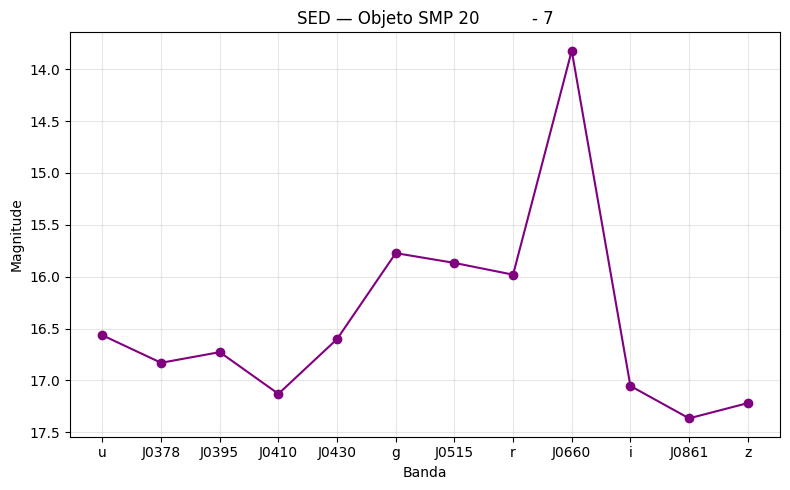

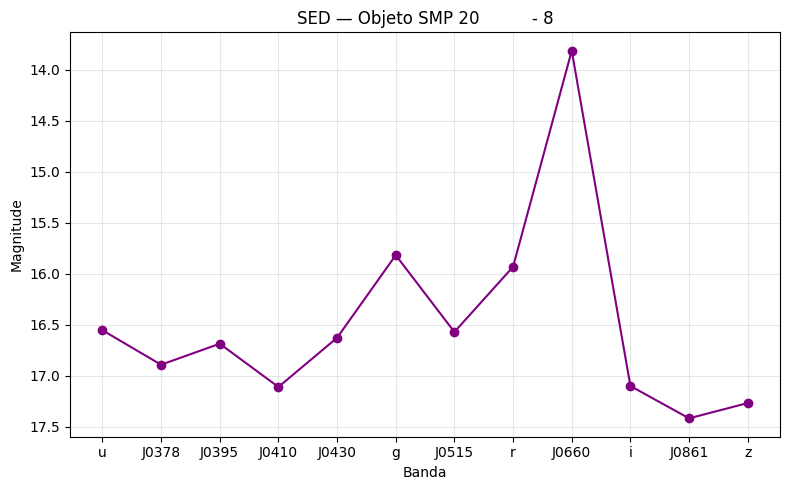

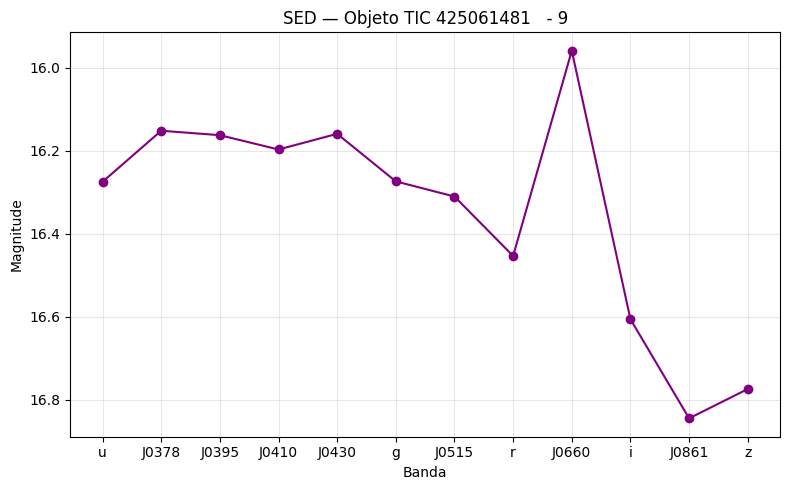

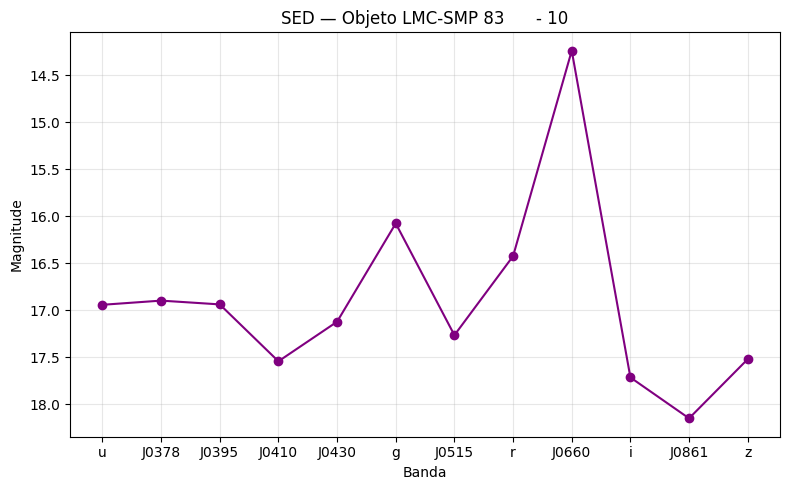

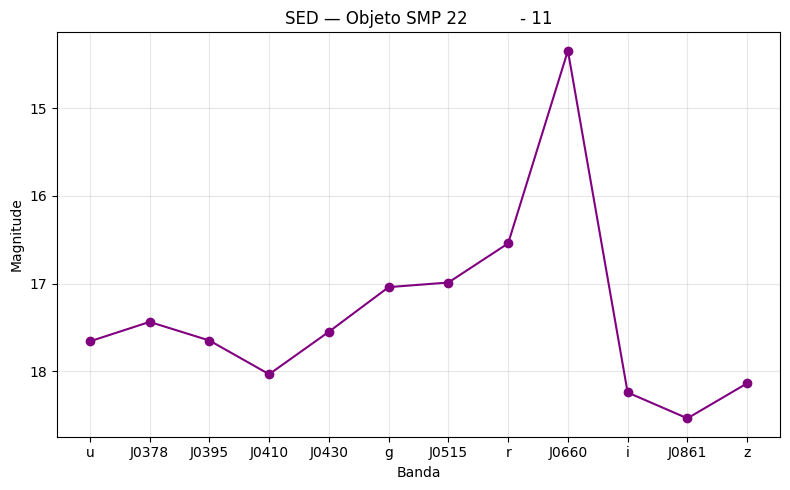

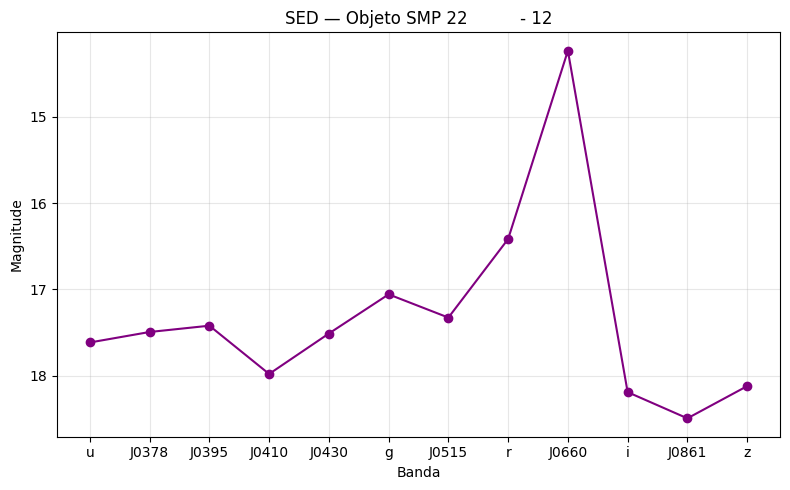

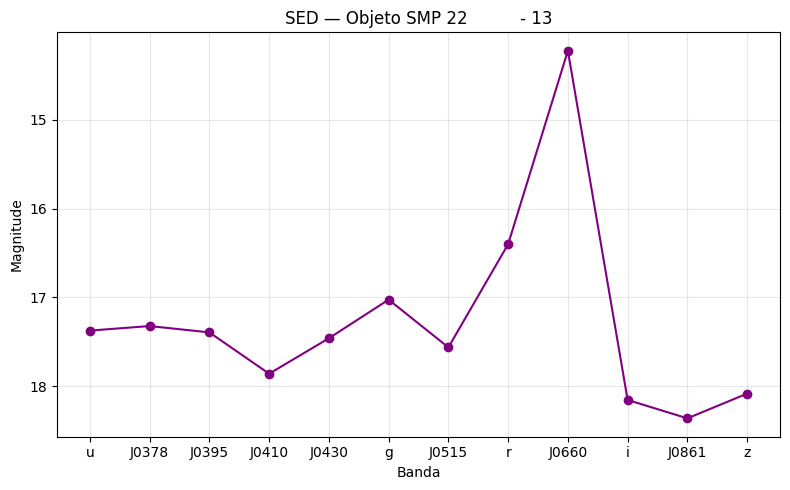

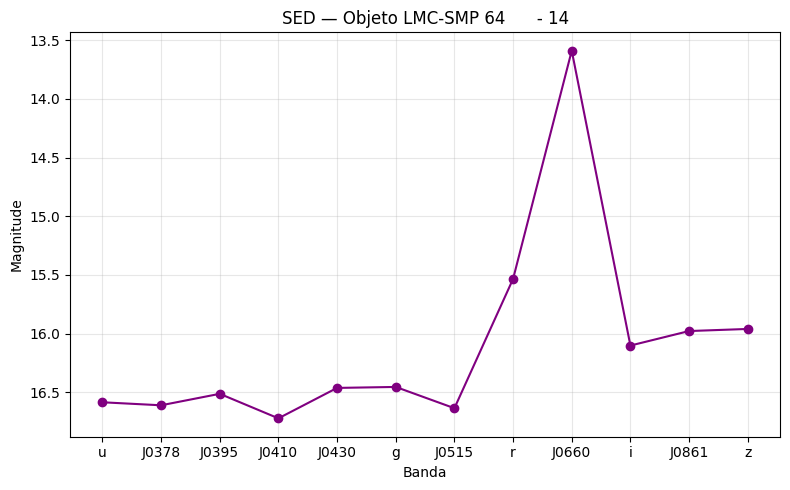

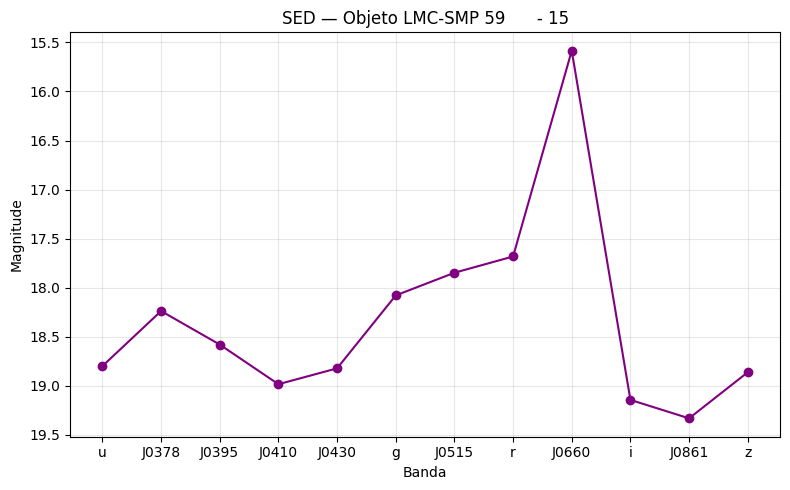

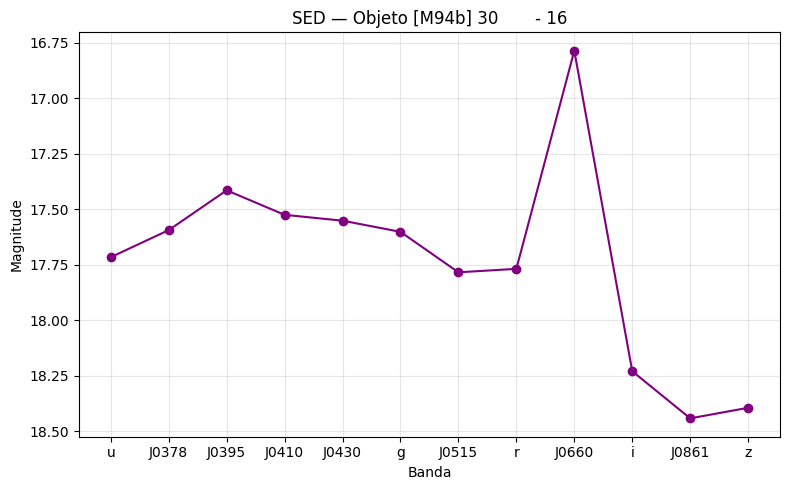

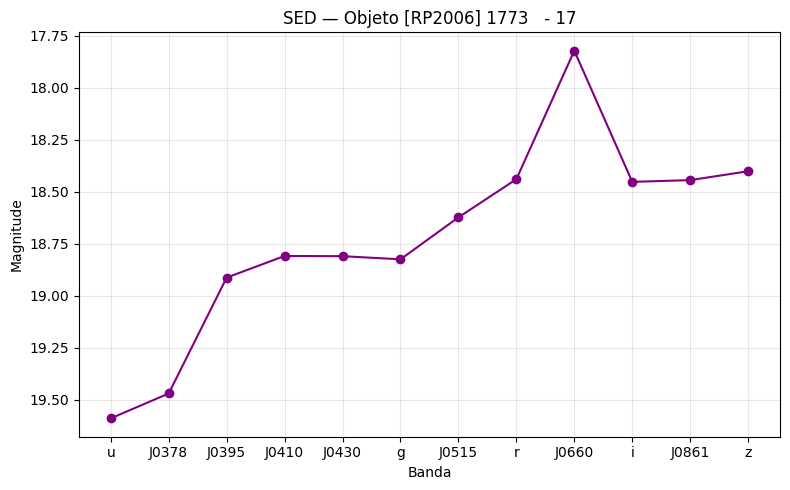

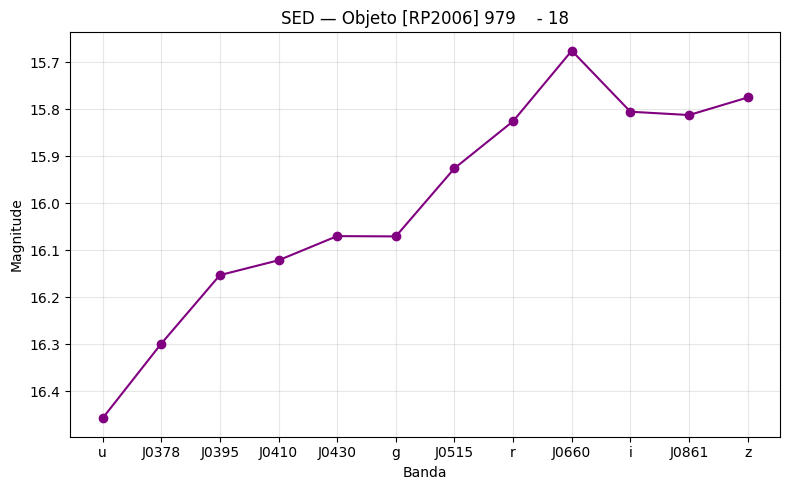

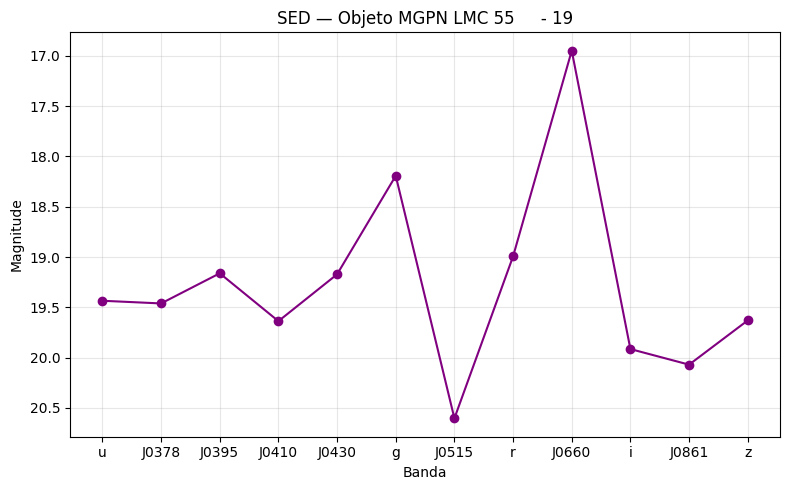

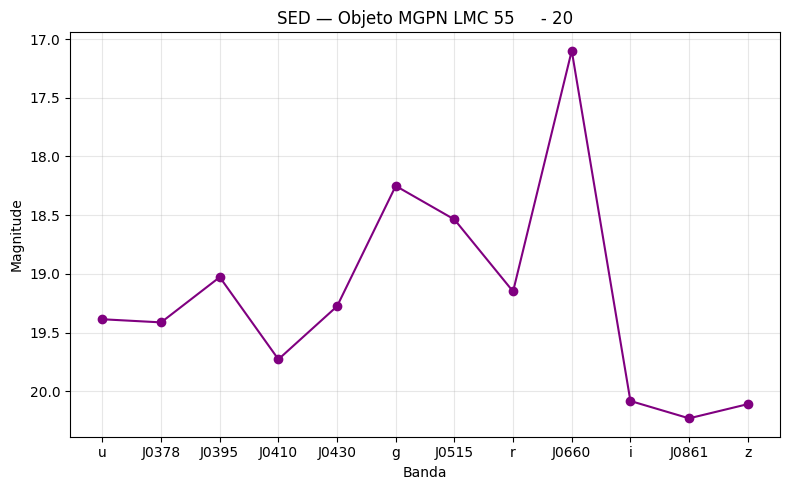

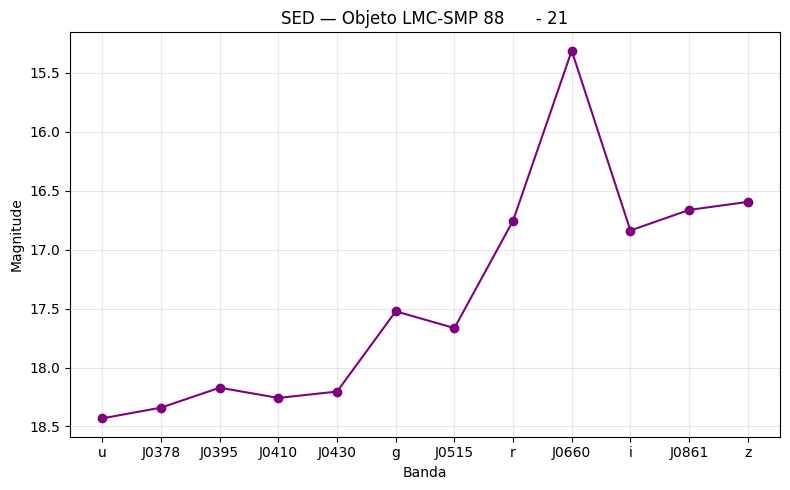

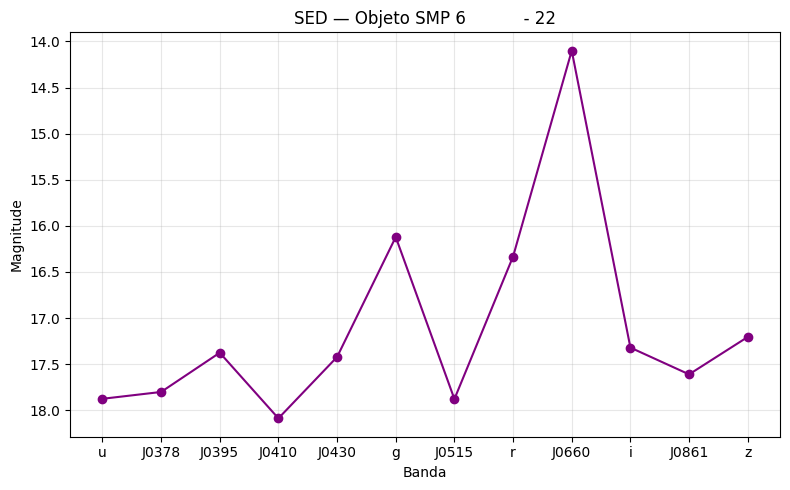

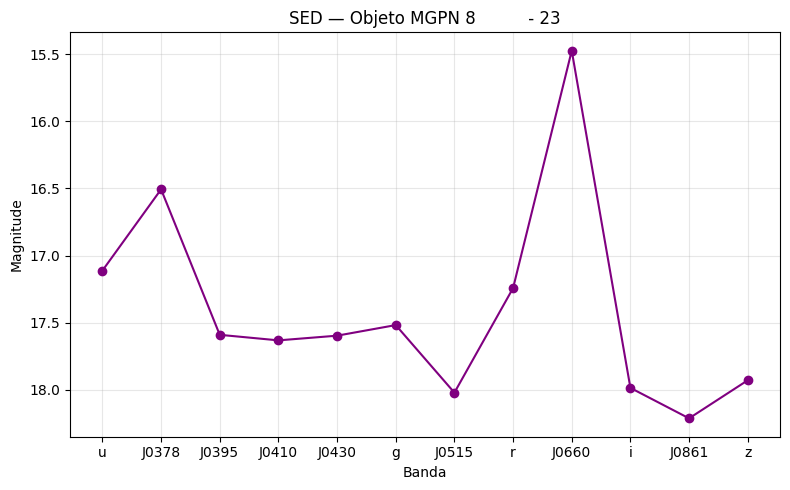

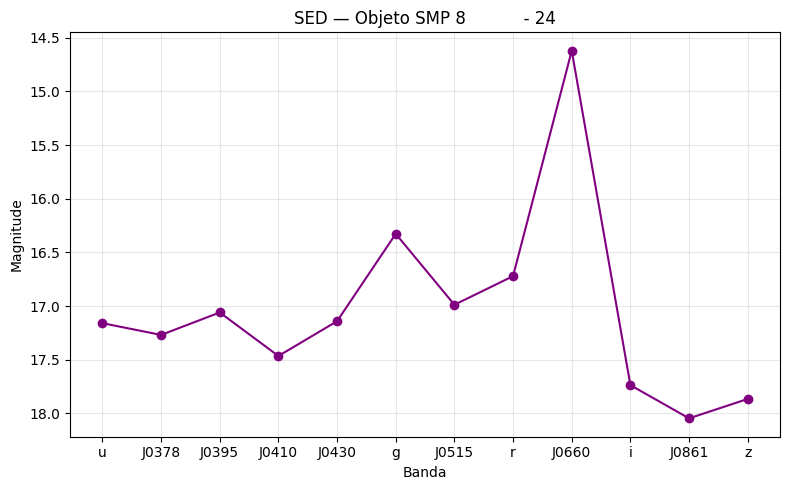

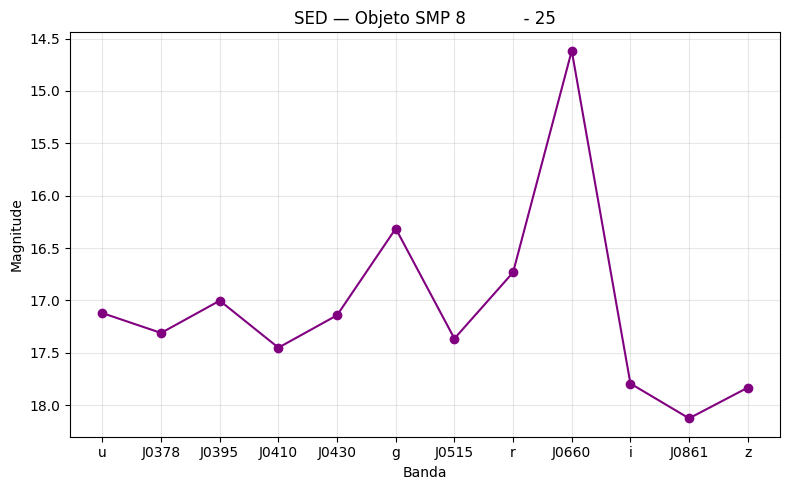

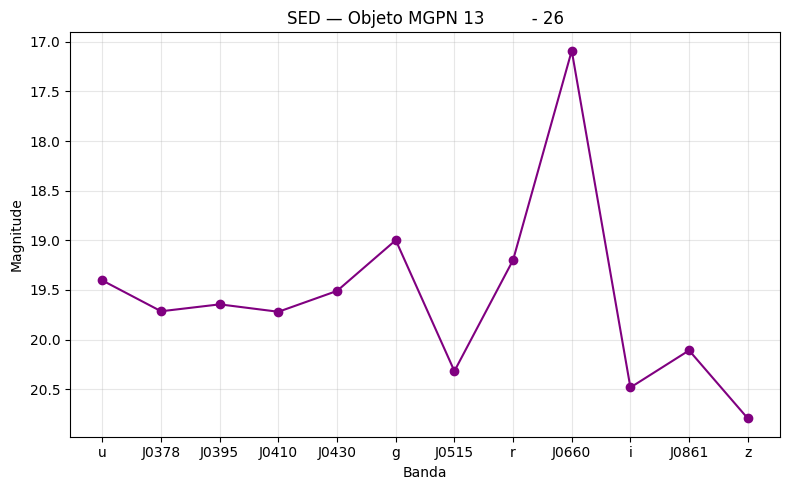

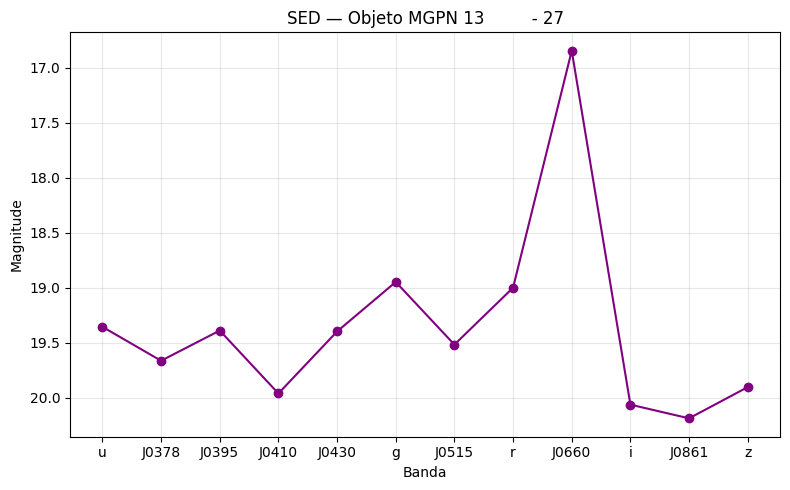

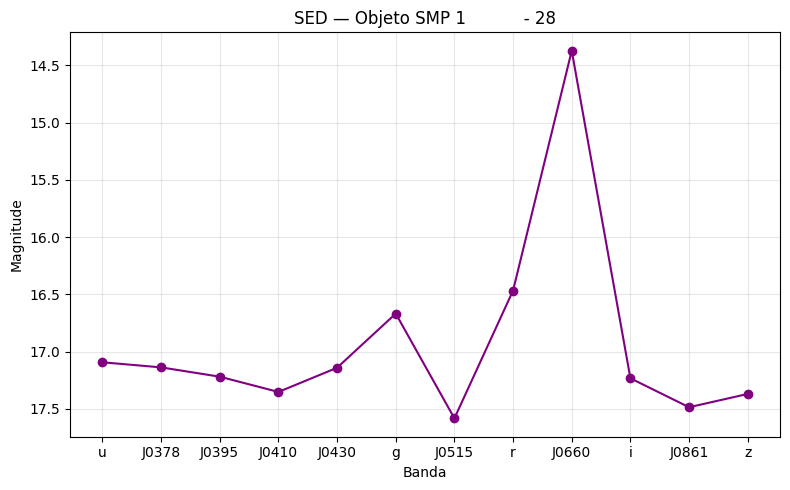

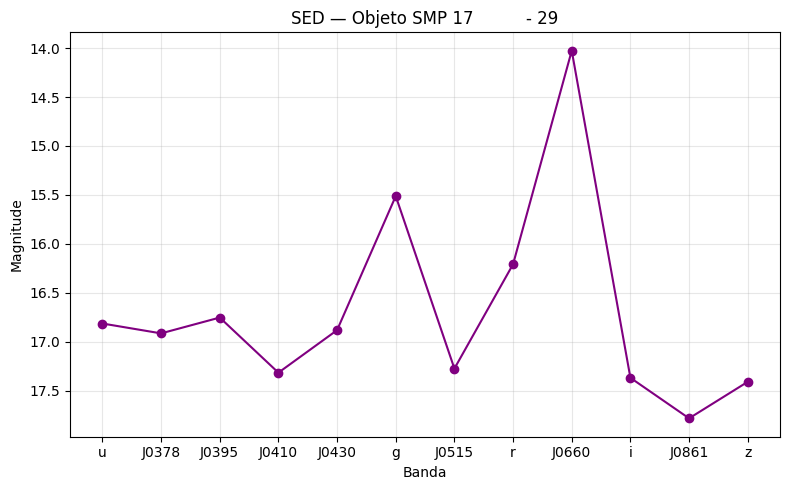

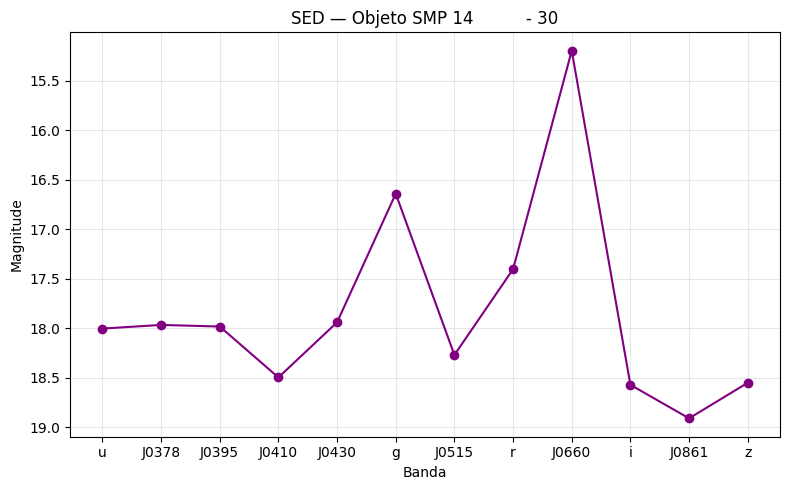

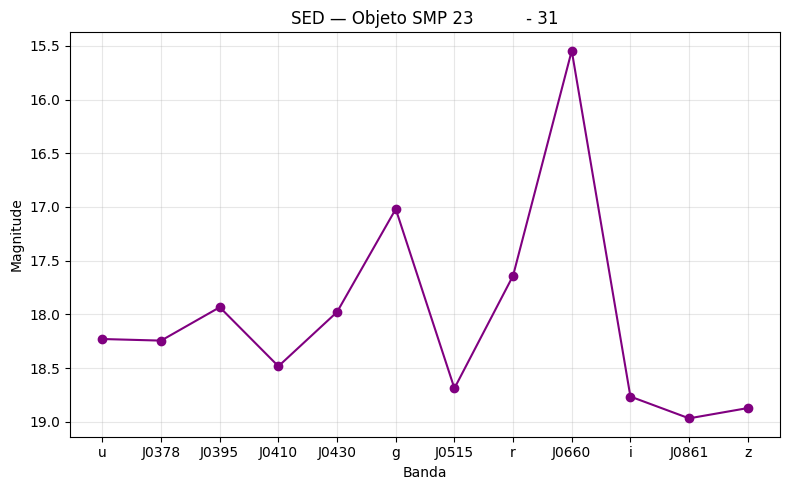

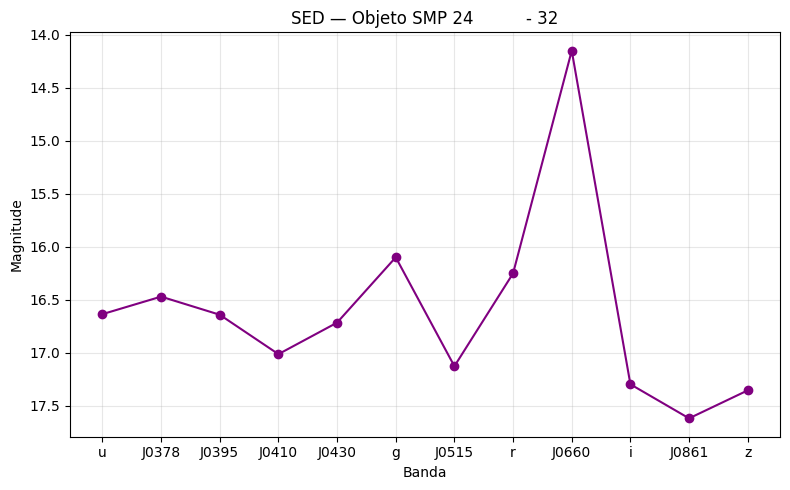

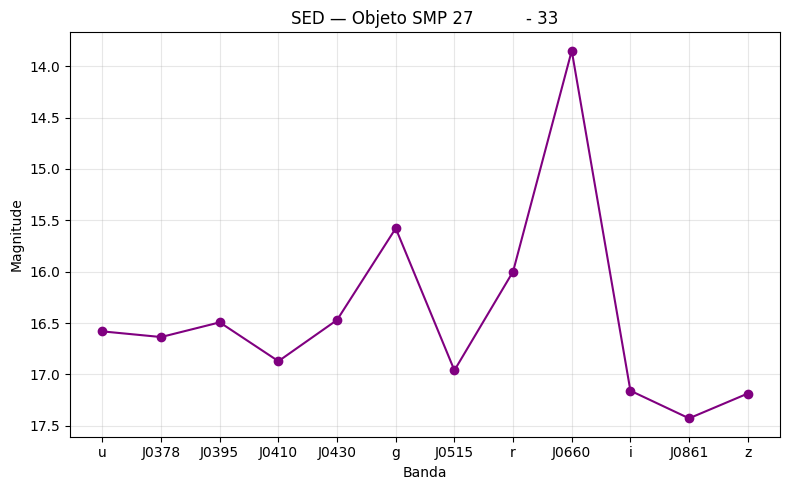

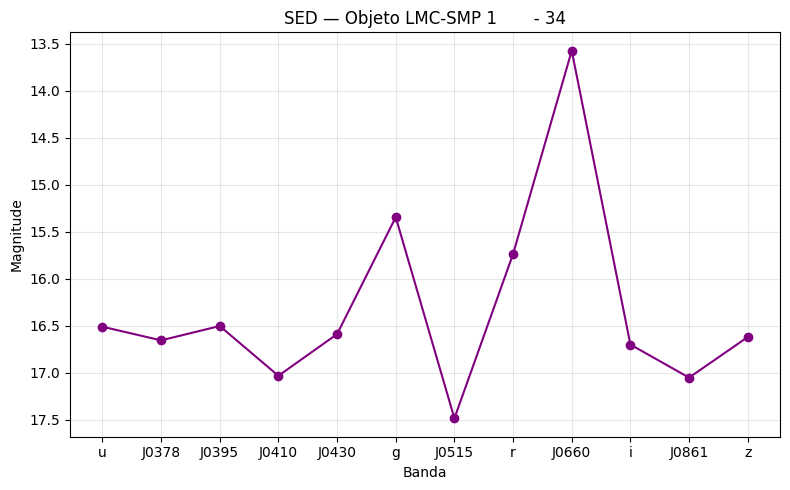

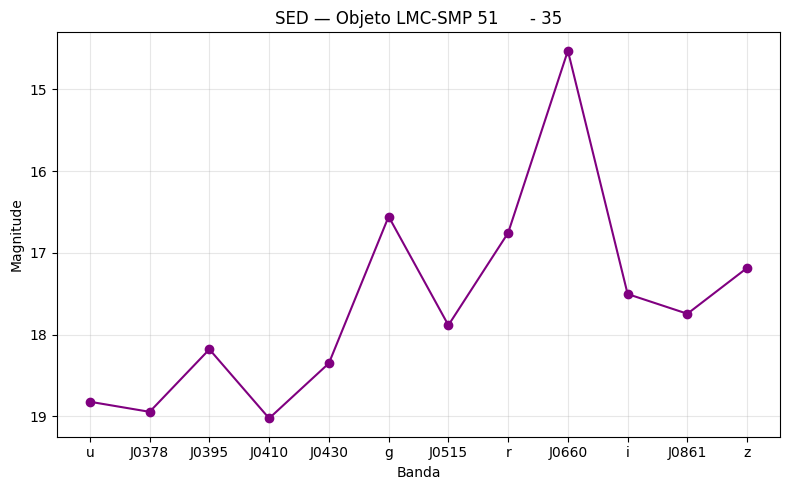

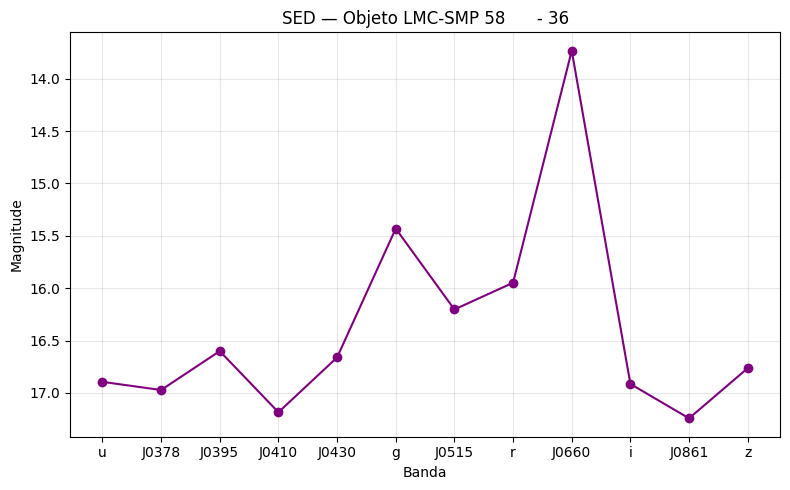

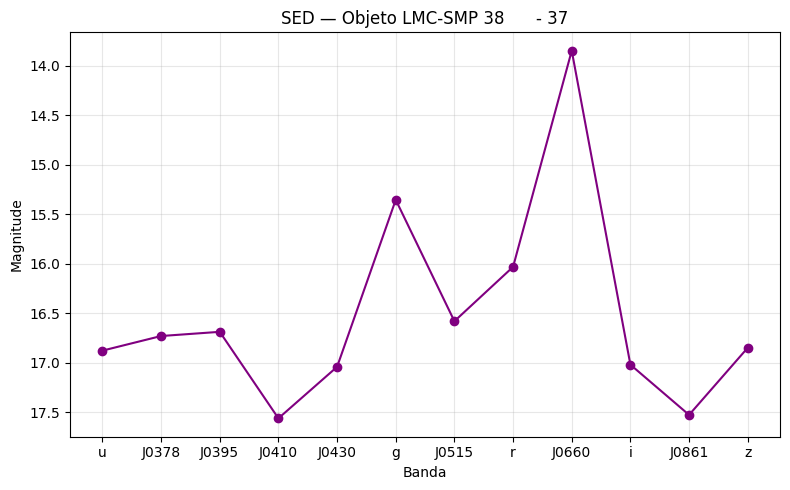

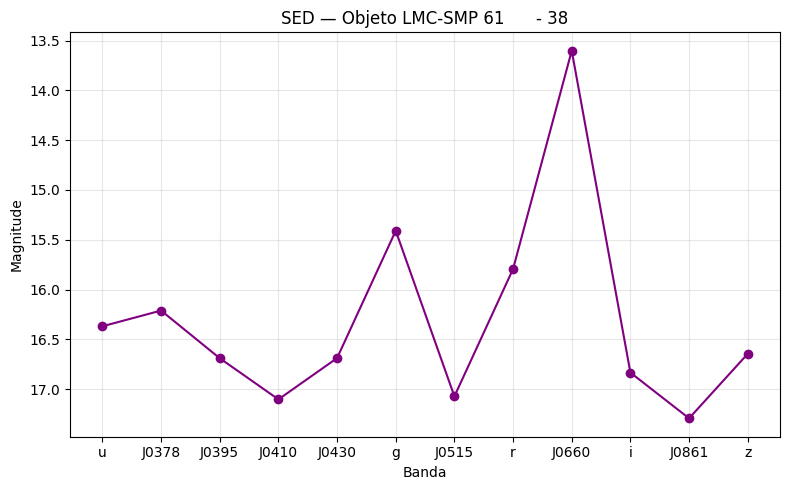

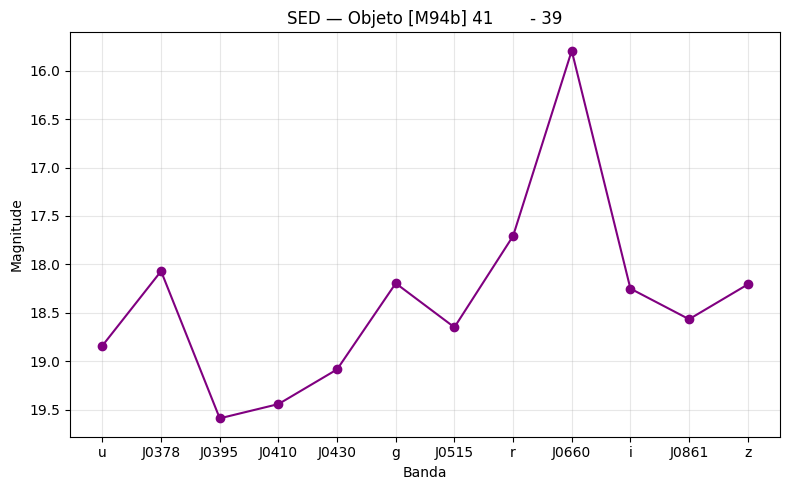

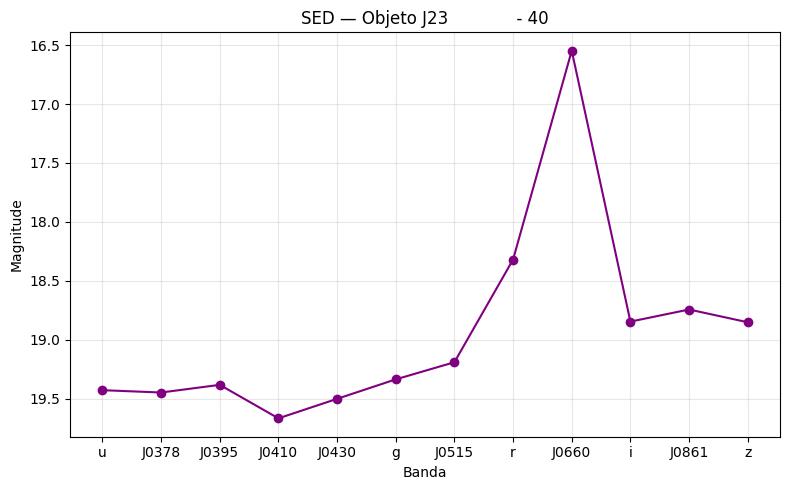

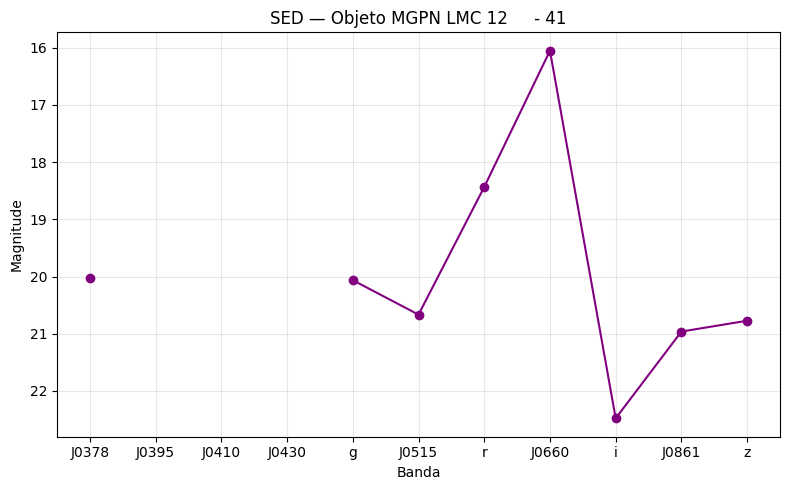

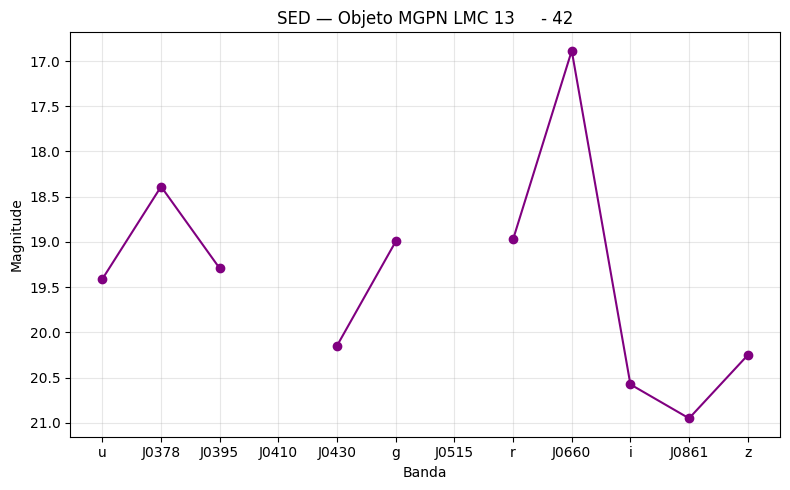

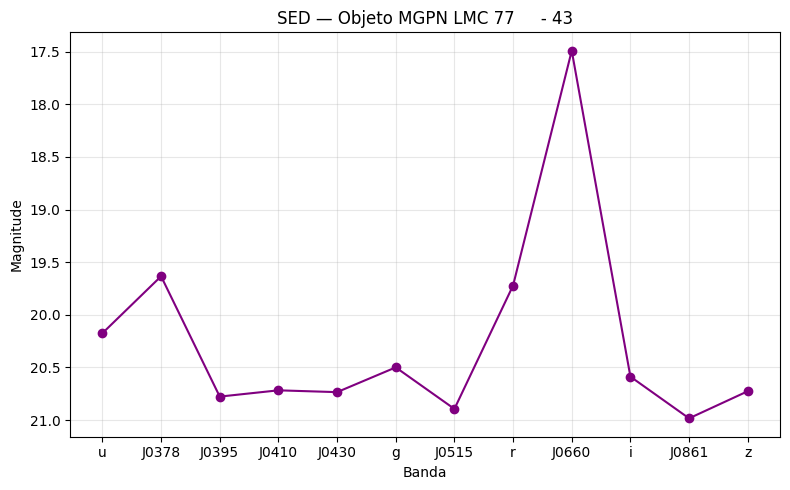

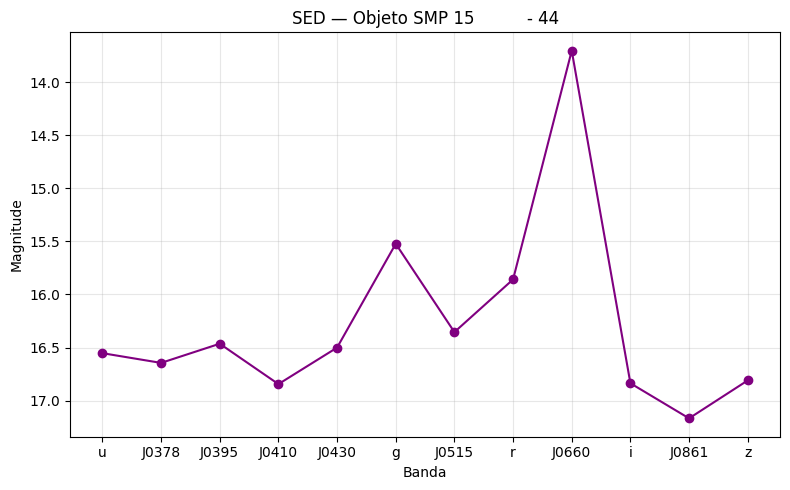

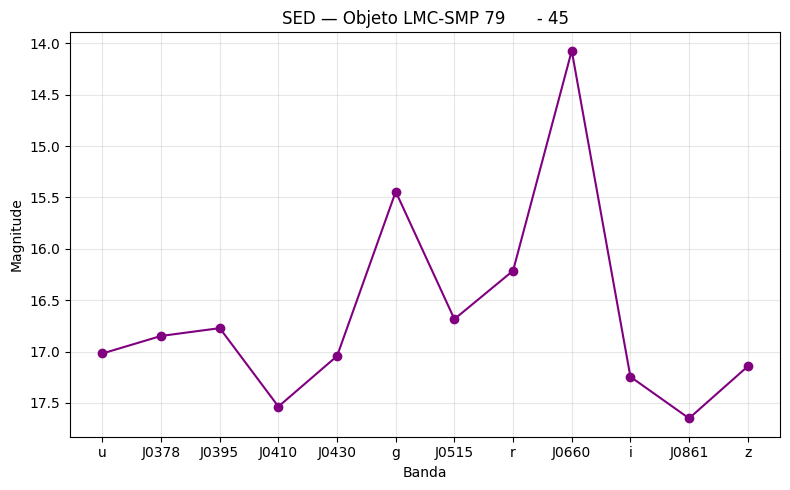

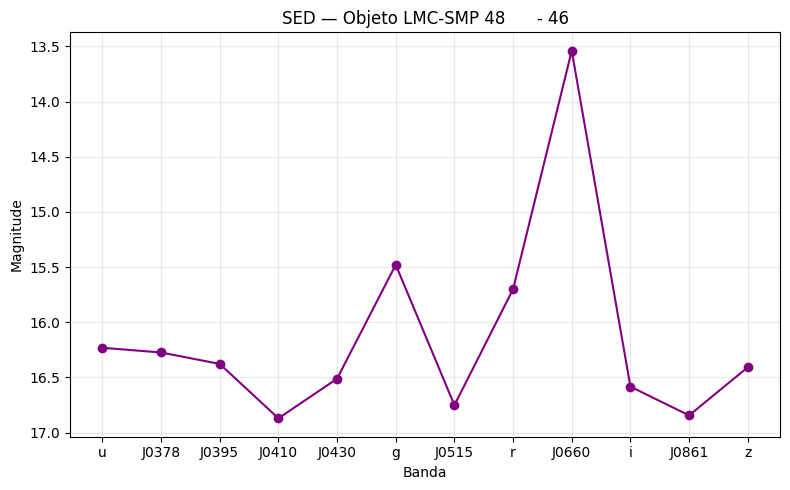

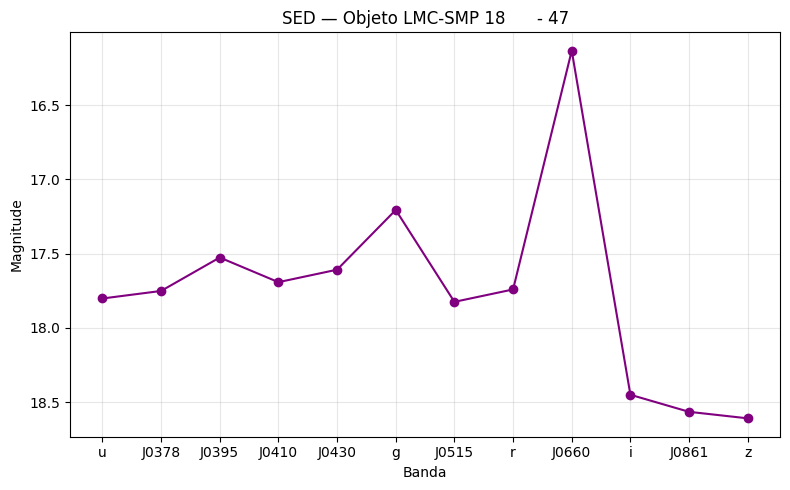

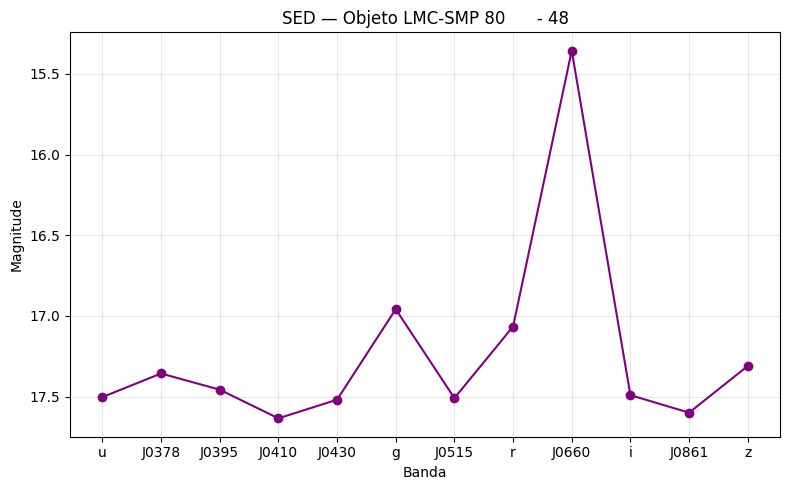

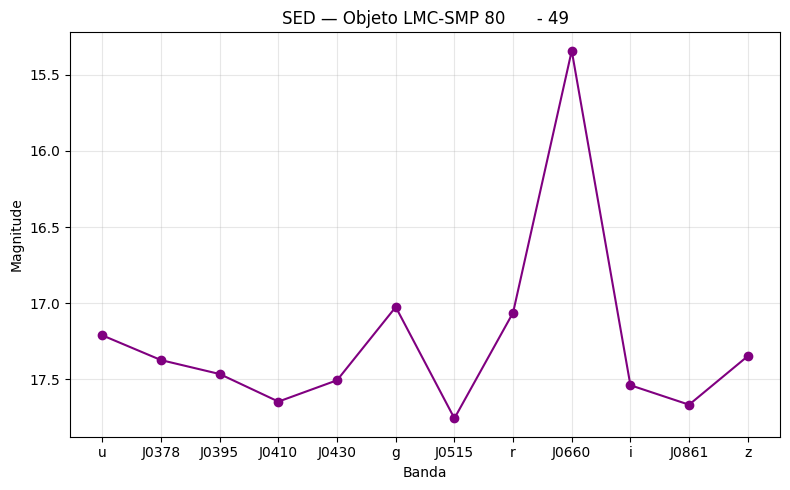

In [12]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"mag_psf_{b.lower()}" for b in bands]
err_cols = [f"err_mag_psf_{b.lower()}" for b in bands]
has_errors = all(col in pne_splus.columns for col in err_cols)

i = 0
for idx, row in pne_splus.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["Name"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

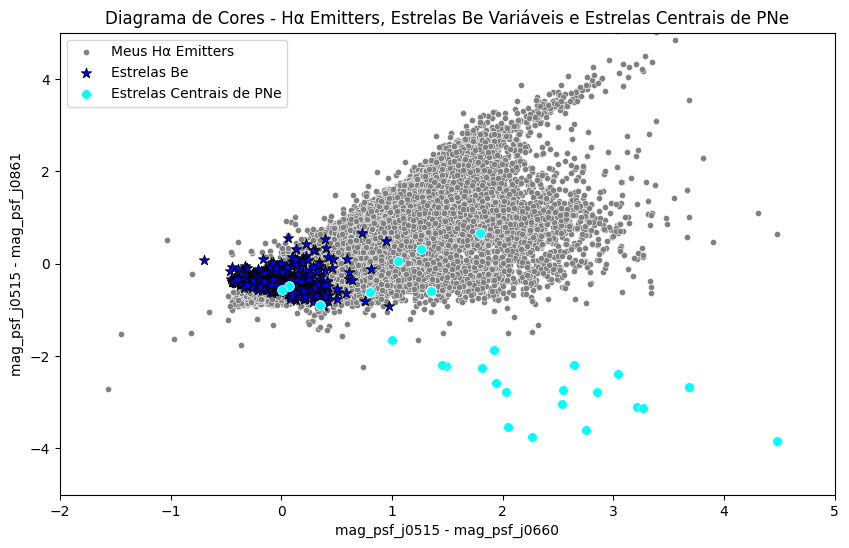

In [78]:
#coloque esse grafico em seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
                y=meus['mag_psf_j0515'] - meus['mag_psf_j0861'], 
                label='Meus Hα Emitters', color='gray', s=20)
sns.scatterplot(x=be['mag_psf_j0515'] - be['mag_psf_j0660'], 
                y=be['mag_psf_j0660'] - be['mag_psf_j0861'], 
                label='Estrelas Be', color='blue', s=60, marker = '*', edgecolor='black')
sns.scatterplot(x=match3['mag_psf_j0515_meus'] - match3['mag_psf_j0660_meus'], 
                y=match3['mag_psf_j0660_meus'] - match3['mag_psf_j0861_meus'], 
                label='Estrelas Centrais de PNe', color='cyan', s=50)
plt.ylim(-5, 5)
plt.xlim(-2, 5)

plt.xlabel('mag_psf_j0515 - mag_psf_j0660')
plt.ylabel('mag_psf_j0515 - mag_psf_j0861')
plt.title('Diagrama de Cores - Hα Emitters, Estrelas Be Variáveis e Estrelas Centrais de PNe')
plt.legend()

plt.show()
